<a href="https://colab.research.google.com/github/mahnoorjunaid/FIS/blob/main/FIS_Credit_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementation & Results**
## Enhancing Credit Risk Assessment via Fuzzy Inference Systems
### Mahnoor Junaid | i235561@isb.nu.edu.pk
---

## Cell 1: Install Dependencies

In [1]:
# ── Install required libraries ──────────────────────────────────────────────
!pip install scikit-fuzzy scikit-learn xgboost imbalanced-learn pandas numpy \
             matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 23.7 MB/s eta 0:00:00


## Cell 2: Imports

In [2]:
# ── Core imports ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# Scikit-fuzzy
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Global plot settings for 300 DPI
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

PALETTE = ['#2E86AB', '#E84855', '#3BB273', '#F4A259', '#7B2D8B']
print('All libraries loaded successfully.')

All libraries loaded successfully.


## Cell 3: Load & Explore Dataset
> Upload `german.data` to Colab or the dataset CSV — the cell below handles both formats.

In [3]:
# ── Load German Credit Dataset ───────────────────────────────────────────────
# Column names for the raw german.data file (space-separated, no header)
col_names = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment', 'installment_rate', 'personal_status',
    'other_parties', 'residence_since', 'property_magnitude', 'age',
    'other_payment_plans', 'housing', 'existing_credits', 'job',
    'num_dependants', 'own_telephone', 'foreign_worker', 'class'
]

df = None # Initialize df to None

try:
    # Try loading raw german.data (space separated, no header)
    df = pd.read_csv('german.data', sep=' ', header=None, names=col_names)
    print('Loaded german.data successfully')
except FileNotFoundError:
    pass # If german.data not found, try the next option

if df is None: # Only try to load german_credit_data.csv if german.data was not found
    try:
        temp_df = pd.read_csv('german_credit_data.csv')
        # If 'Risk' column exists, rename it to 'class' and use this df
        if 'Risk' in temp_df.columns:
            df = temp_df.rename(columns={'Risk': 'class'})
            print('Loaded CSV version and renamed "Risk" to "class"')
        else:
            # If german_credit_data.csv does not contain a 'Risk' column, it's likely not the intended dataset.
            # Proceed to download from UCI instead of using this potentially incorrect CSV.
            print("Warning: 'german_credit_data.csv' found but does not contain a 'Risk' column. Attempting UCI download.")
            raise FileNotFoundError("Incorrect 'german_credit_data.csv' structure") # Force fallback
    except FileNotFoundError:
        pass # If german_credit_data.csv not found or was incorrect, try the fallback

if df is None: # If neither local file loaded successfully
    # Fallback: download directly from UCI
    import urllib.request
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
    urllib.request.urlretrieve(url, 'german.data')
    df = pd.read_csv('german.data', sep=' ', header=None, names=col_names)
    print('Downloaded and loaded from UCI repository')

# This assumes df is now correctly loaded with a 'class' column
# Convert target: 1=good -> 0 (no default), 2=bad -> 1 (default)
if df['class'].max() == 2:
    df['class'] = df['class'].map({1: 0, 2: 1})

print(f'\nDataset shape: {df.shape}')
print(f'Class distribution:\n{df["class"].value_counts()}')
print(f'\nClass balance: {df["class"].value_counts(normalize=True).round(3).to_dict()}')
df.head()

Downloaded and loaded from UCI repository

Dataset shape: (1000, 21)
Class distribution:
class
0    700
1    300
Name: count, dtype: int64

Class balance: {0: 0.7, 1: 0.3}


,checking_status,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependants,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## Cell 4: Data Preprocessing

In [4]:
# ── Preprocessing ────────────────────────────────────────────────────────────

df_proc = df.copy()

# Separate features and target
X_raw = df_proc.drop('class', axis=1)
y = df_proc['class'].values

# Identify column types
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(exclude='object').columns.tolist()

# Imputation: median for numeric, mode for categorical
for col in num_cols:
    X_raw[col].fillna(X_raw[col].median(), inplace=True)
for col in cat_cols:
    X_raw[col].fillna(X_raw[col].mode()[0], inplace=True)

# Encode categoricals with ordinal/label encoding
le = LabelEncoder()
for col in cat_cols:
    X_raw[col] = le.fit_transform(X_raw[col].astype(str))

X = X_raw.values
feature_names = X_raw.columns.tolist()

# Train-test split BEFORE SMOTE (80:20 stratified)
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_raw, y_train_raw)

# Min-Max scaling
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print(f'Training set after SMOTE: {X_train_sc.shape}')
print(f'Test set:                 {X_test_sc.shape}')
print(f'SMOTE class distribution: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}')

Training set after SMOTE: (1120, 20)
Test set:                 (200, 20)
SMOTE class distribution: {np.int64(0): np.int64(560), np.int64(1): np.int64(560)}


## Cell 5: Feature Selection (Fisher Score + RFE)

In [5]:
# ── Feature Selection ────────────────────────────────────────────────────────

# Stage 1: Fisher Score (ANOVA F-score as proxy)
fisher = SelectKBest(score_func=f_classif, k='all')
fisher.fit(X_train_sc, y_train_sm)
fisher_scores = fisher.scores_

# Stage 2: RFE with logistic regression to select top 8
lr_rfe = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(lr_rfe, n_features_to_select=8)
rfe.fit(X_train_sc, y_train_sm)
selected_mask = rfe.support_

selected_features = [feature_names[i] for i in range(len(feature_names)) if selected_mask[i]]
print('Selected features:', selected_features)

X_train_sel = X_train_sc[:, selected_mask]
X_test_sel  = X_test_sc[:, selected_mask]

# Map to our 8 FIS variables (by name proximity)
FIS_FEATURE_MAP = {
    'credit_amount': 'credit_amount',
    'duration':      'duration',
    'checking_status': 'checking_status',
    'employment':    'employment',
    'savings_account': 'savings_account',
    'installment_rate': 'installment_rate',
    'age':           'age',
    'purpose':       'purpose'
}

TARGET_COLS = list(FIS_FEATURE_MAP.keys())
target_idx = [feature_names.index(c) for c in TARGET_COLS if c in feature_names]

X_train_fis = X_train_sc[:, target_idx]
X_test_fis  = X_test_sc[:, target_idx]
print(f'FIS input shape: {X_train_fis.shape}')

Selected features: ['checking_status', 'duration', 'credit_history', 'savings_account', 'employment', 'personal_status', 'other_payment_plans', 'foreign_worker']
FIS input shape: (1120, 8)


## Cell 6: Mamdani FIS Design

In [6]:
# ── Mamdani FIS Design ───────────────────────────────────────────────────────
# All inputs normalised [0, 1] by MinMaxScaler

u = np.linspace(0, 1, 100)  # universe of discourse

# ── Input antecedents ───────────────────────────────────────────────────────
credit_amount    = ctrl.Antecedent(u, 'credit_amount')
duration         = ctrl.Antecedent(u, 'duration')
checking_status  = ctrl.Antecedent(u, 'checking_status')
employment       = ctrl.Antecedent(u, 'employment')
savings_account  = ctrl.Antecedent(u, 'savings_account')
installment_rate = ctrl.Antecedent(u, 'installment_rate')
age              = ctrl.Antecedent(u, 'age')
purpose          = ctrl.Antecedent(u, 'purpose')

# ── Output consequent ───────────────────────────────────────────────────────
risk = ctrl.Consequent(u, 'risk')

# ── Membership functions ─────────────────────────────────────────────────────
# Credit Amount: Low / Medium / High
credit_amount['Low']    = fuzz.trimf(u, [0, 0, 0.4])
credit_amount['Medium'] = fuzz.trimf(u, [0.2, 0.5, 0.8])
credit_amount['High']   = fuzz.trimf(u, [0.6, 1, 1])

# Duration: Short / Medium / Long
duration['Short']  = fuzz.trimf(u, [0, 0, 0.4])
duration['Medium'] = fuzz.trimf(u, [0.2, 0.5, 0.8])
duration['Long']   = fuzz.trimf(u, [0.6, 1, 1])

# Checking Status: Poor / Moderate / Good
checking_status['Poor']     = fuzz.trimf(u, [0, 0, 0.4])
checking_status['Moderate'] = fuzz.trimf(u, [0.2, 0.5, 0.8])
checking_status['Good']     = fuzz.trimf(u, [0.6, 1, 1])

# Employment: Unstable / Moderate / Stable
employment['Unstable'] = fuzz.trimf(u, [0, 0, 0.4])
employment['Moderate'] = fuzz.trimf(u, [0.2, 0.5, 0.8])
employment['Stable']   = fuzz.trimf(u, [0.6, 1, 1])

# Savings Account: Low / Medium / High
savings_account['Low']    = fuzz.trimf(u, [0, 0, 0.4])
savings_account['Medium'] = fuzz.trimf(u, [0.2, 0.5, 0.8])
savings_account['High']   = fuzz.trimf(u, [0.6, 1, 1])

# Installment Rate: Low / Moderate / High
installment_rate['Low']      = fuzz.trimf(u, [0, 0, 0.4])
installment_rate['Moderate'] = fuzz.trimf(u, [0.2, 0.5, 0.8])
installment_rate['High']     = fuzz.trimf(u, [0.6, 1, 1])

# Age: Young / Middle / Senior
age['Young']  = fuzz.trimf(u, [0, 0, 0.4])
age['Middle'] = fuzz.trimf(u, [0.2, 0.5, 0.8])
age['Senior'] = fuzz.trimf(u, [0.6, 1, 1])

# Purpose: Productive / Consumptive  (binary)
purpose['Productive']   = fuzz.trimf(u, [0, 0, 0.5])
purpose['Consumptive']  = fuzz.trimf(u, [0.5, 1, 1])

# Risk output: Very Low / Low / Medium / High / Very High
risk['VeryLow']  = fuzz.trimf(u, [0, 0,    0.25])
risk['Low']      = fuzz.trimf(u, [0, 0.25, 0.50])
risk['Medium']   = fuzz.trimf(u, [0.25, 0.50, 0.75])
risk['High']     = fuzz.trimf(u, [0.50, 0.75, 1.0])
risk['VeryHigh'] = fuzz.trimf(u, [0.75, 1,   1.0])

print('FIS antecedents and consequent defined.')

FIS antecedents and consequent defined.


## Cell 7: Rule Base Definition

In [7]:
# ── Expert-derived If-Then Rule Base (25 rules) ──────────────────────────────

rules = [
    # Strong good-risk signals
    ctrl.Rule(checking_status['Good']  & employment['Stable']   & savings_account['High'],   risk['VeryLow']),
    ctrl.Rule(checking_status['Good']  & credit_amount['Low']   & duration['Short'],          risk['VeryLow']),
    ctrl.Rule(savings_account['High']  & installment_rate['Low'] & employment['Stable'],       risk['VeryLow']),
    ctrl.Rule(age['Senior']            & checking_status['Good'] & savings_account['Medium'],  risk['Low']),
    ctrl.Rule(employment['Stable']     & credit_amount['Low']   & installment_rate['Low'],    risk['Low']),

    # Moderate good-risk signals
    ctrl.Rule(checking_status['Moderate'] & employment['Moderate'] & savings_account['Medium'], risk['Low']),
    ctrl.Rule(age['Middle']            & credit_amount['Medium'] & duration['Medium'],         risk['Medium']),
    ctrl.Rule(purpose['Productive']    & checking_status['Good'] & employment['Moderate'],     risk['Low']),
    ctrl.Rule(purpose['Productive']    & savings_account['Medium'] & installment_rate['Moderate'], risk['Medium']),
    ctrl.Rule(checking_status['Moderate'] & credit_amount['High'] & duration['Short'],         risk['Medium']),

    # Moderate bad-risk signals
    ctrl.Rule(checking_status['Poor']  & credit_amount['High']  & duration['Long'],            risk['VeryHigh']),
    ctrl.Rule(checking_status['Poor']  & savings_account['Low'] & installment_rate['High'],    risk['VeryHigh']),
    ctrl.Rule(employment['Unstable']   & credit_amount['High']  & savings_account['Low'],      risk['High']),
    ctrl.Rule(installment_rate['High'] & duration['Long']       & savings_account['Low'],      risk['High']),
    ctrl.Rule(age['Young']             & credit_amount['High']  & employment['Unstable'],      risk['High']),

    # Mixed signals - medium risk
    ctrl.Rule(checking_status['Poor']  & employment['Stable']   & savings_account['Medium'],   risk['Medium']),
    ctrl.Rule(credit_amount['High']    & duration['Long']       & employment['Moderate'],       risk['High']),
    ctrl.Rule(purpose['Consumptive']   & credit_amount['High']  & savings_account['Low'],      risk['High']),
    ctrl.Rule(purpose['Consumptive']   & installment_rate['High'] & employment['Unstable'],    risk['VeryHigh']),
    ctrl.Rule(age['Young']             & purpose['Consumptive'] & installment_rate['High'],    risk['High']),

    # Additional nuanced rules
    ctrl.Rule(savings_account['Low']   & checking_status['Poor'] & duration['Medium'],         risk['High']),
    ctrl.Rule(employment['Stable']     & savings_account['High'] & credit_amount['Medium'],    risk['Low']),
    ctrl.Rule(checking_status['Good']  & installment_rate['High'] & duration['Long'],          risk['Medium']),
    ctrl.Rule(age['Middle']            & employment['Moderate']  & savings_account['Low'],     risk['Medium']),
    ctrl.Rule(purpose['Productive']    & savings_account['High'] & age['Senior'],              risk['VeryLow']),
]

print(f'Rule base size: {len(rules)} rules defined.')

Rule base size: 25 rules defined.


## Cell 8: FIS Inference & Prediction

In [8]:
# ── Build FIS control system ─────────────────────────────────────────────────

credit_ctrl = ctrl.ControlSystem(rules)
fis_sim     = ctrl.ControlSystemSimulation(credit_ctrl)

FEATURE_KEYS = [
    'credit_amount', 'duration', 'checking_status',
    'employment', 'savings_account', 'installment_rate',
    'age', 'purpose'
]

def fis_predict_proba(X_input):
    """Run FIS inference for each sample. Returns array of PD scores [0,1]."""
    scores = []
    for row in X_input:
        try:
            for i, key in enumerate(FEATURE_KEYS):
                val = float(np.clip(row[i], 0.001, 0.999))  # avoid boundary issues
                fis_sim.input[key] = val
            fis_sim.compute()
            scores.append(fis_sim.output['risk'])
        except Exception:
            scores.append(0.5)  # fallback for edge cases
    return np.array(scores)

print('Running FIS inference on test set (this may take ~30–60 seconds)...')
fis_proba_test = fis_predict_proba(X_test_fis)

# Apply decision threshold 0.40
THRESHOLD = 0.40
fis_pred_test = (fis_proba_test >= THRESHOLD).astype(int)

print(f'FIS inference complete. Score range: [{fis_proba_test.min():.3f}, {fis_proba_test.max():.3f}]')
print(f'Predicted defaults at threshold {THRESHOLD}: {fis_pred_test.sum()}/{len(fis_pred_test)}')

Running FIS inference on test set (this may take ~30–60 seconds)...
FIS inference complete. Score range: [0.083, 0.917]
Predicted defaults at threshold 0.4: 121/200


## Cell 9: Baseline Models

In [9]:
# ── Logistic Regression Baseline ─────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_sc, y_train_sm)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]
lr_pred  = lr.predict(X_test_sc)

# ── XGBoost Baseline ─────────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb.fit(X_train_sc, y_train_sm)
xgb_proba = xgb.predict_proba(X_test_sc)[:, 1]
xgb_pred  = xgb.predict(X_test_sc)

print('Baselines trained.')

# ── Compile all metrics ───────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_proba, name):
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    type1_err = fp / (fp + tn) if (fp + tn) > 0 else 0   # FPR: safe rejected
    type2_err = fn / (fn + tp) if (fn + tp) > 0 else 0   # FNR: defaults missed
    return {
        'Model':     name,
        'AUC-ROC':   round(roc_auc_score(y_true, y_proba), 4),
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Type I Error':  round(type1_err, 4),
        'Type II Error': round(type2_err, 4),
    }

metrics_fis = compute_metrics(y_test, fis_pred_test, fis_proba_test, 'Mamdani FIS')
metrics_lr  = compute_metrics(y_test, lr_pred,       lr_proba,       'Logistic Regression')
metrics_xgb = compute_metrics(y_test, xgb_pred,      xgb_proba,      'XGBoost')

results_df = pd.DataFrame([metrics_fis, metrics_lr, metrics_xgb])
print('\n── Performance Summary ──')
print(results_df.to_string(index=False))

Baselines trained.

── Performance Summary ──
              Model  AUC-ROC  Accuracy  Precision  Recall  F1 Score  Type I Error  Type II Error
        Mamdani FIS   0.7515     0.595     0.4132  0.8333    0.5525        0.5071         0.1667
Logistic Regression   0.7882     0.740     0.5556  0.6667    0.6061        0.2286         0.3333
            XGBoost   0.8073     0.760     0.6111  0.5500    0.5789        0.1500         0.4500


## Cell 10: GRAPH 1 — Membership Functions

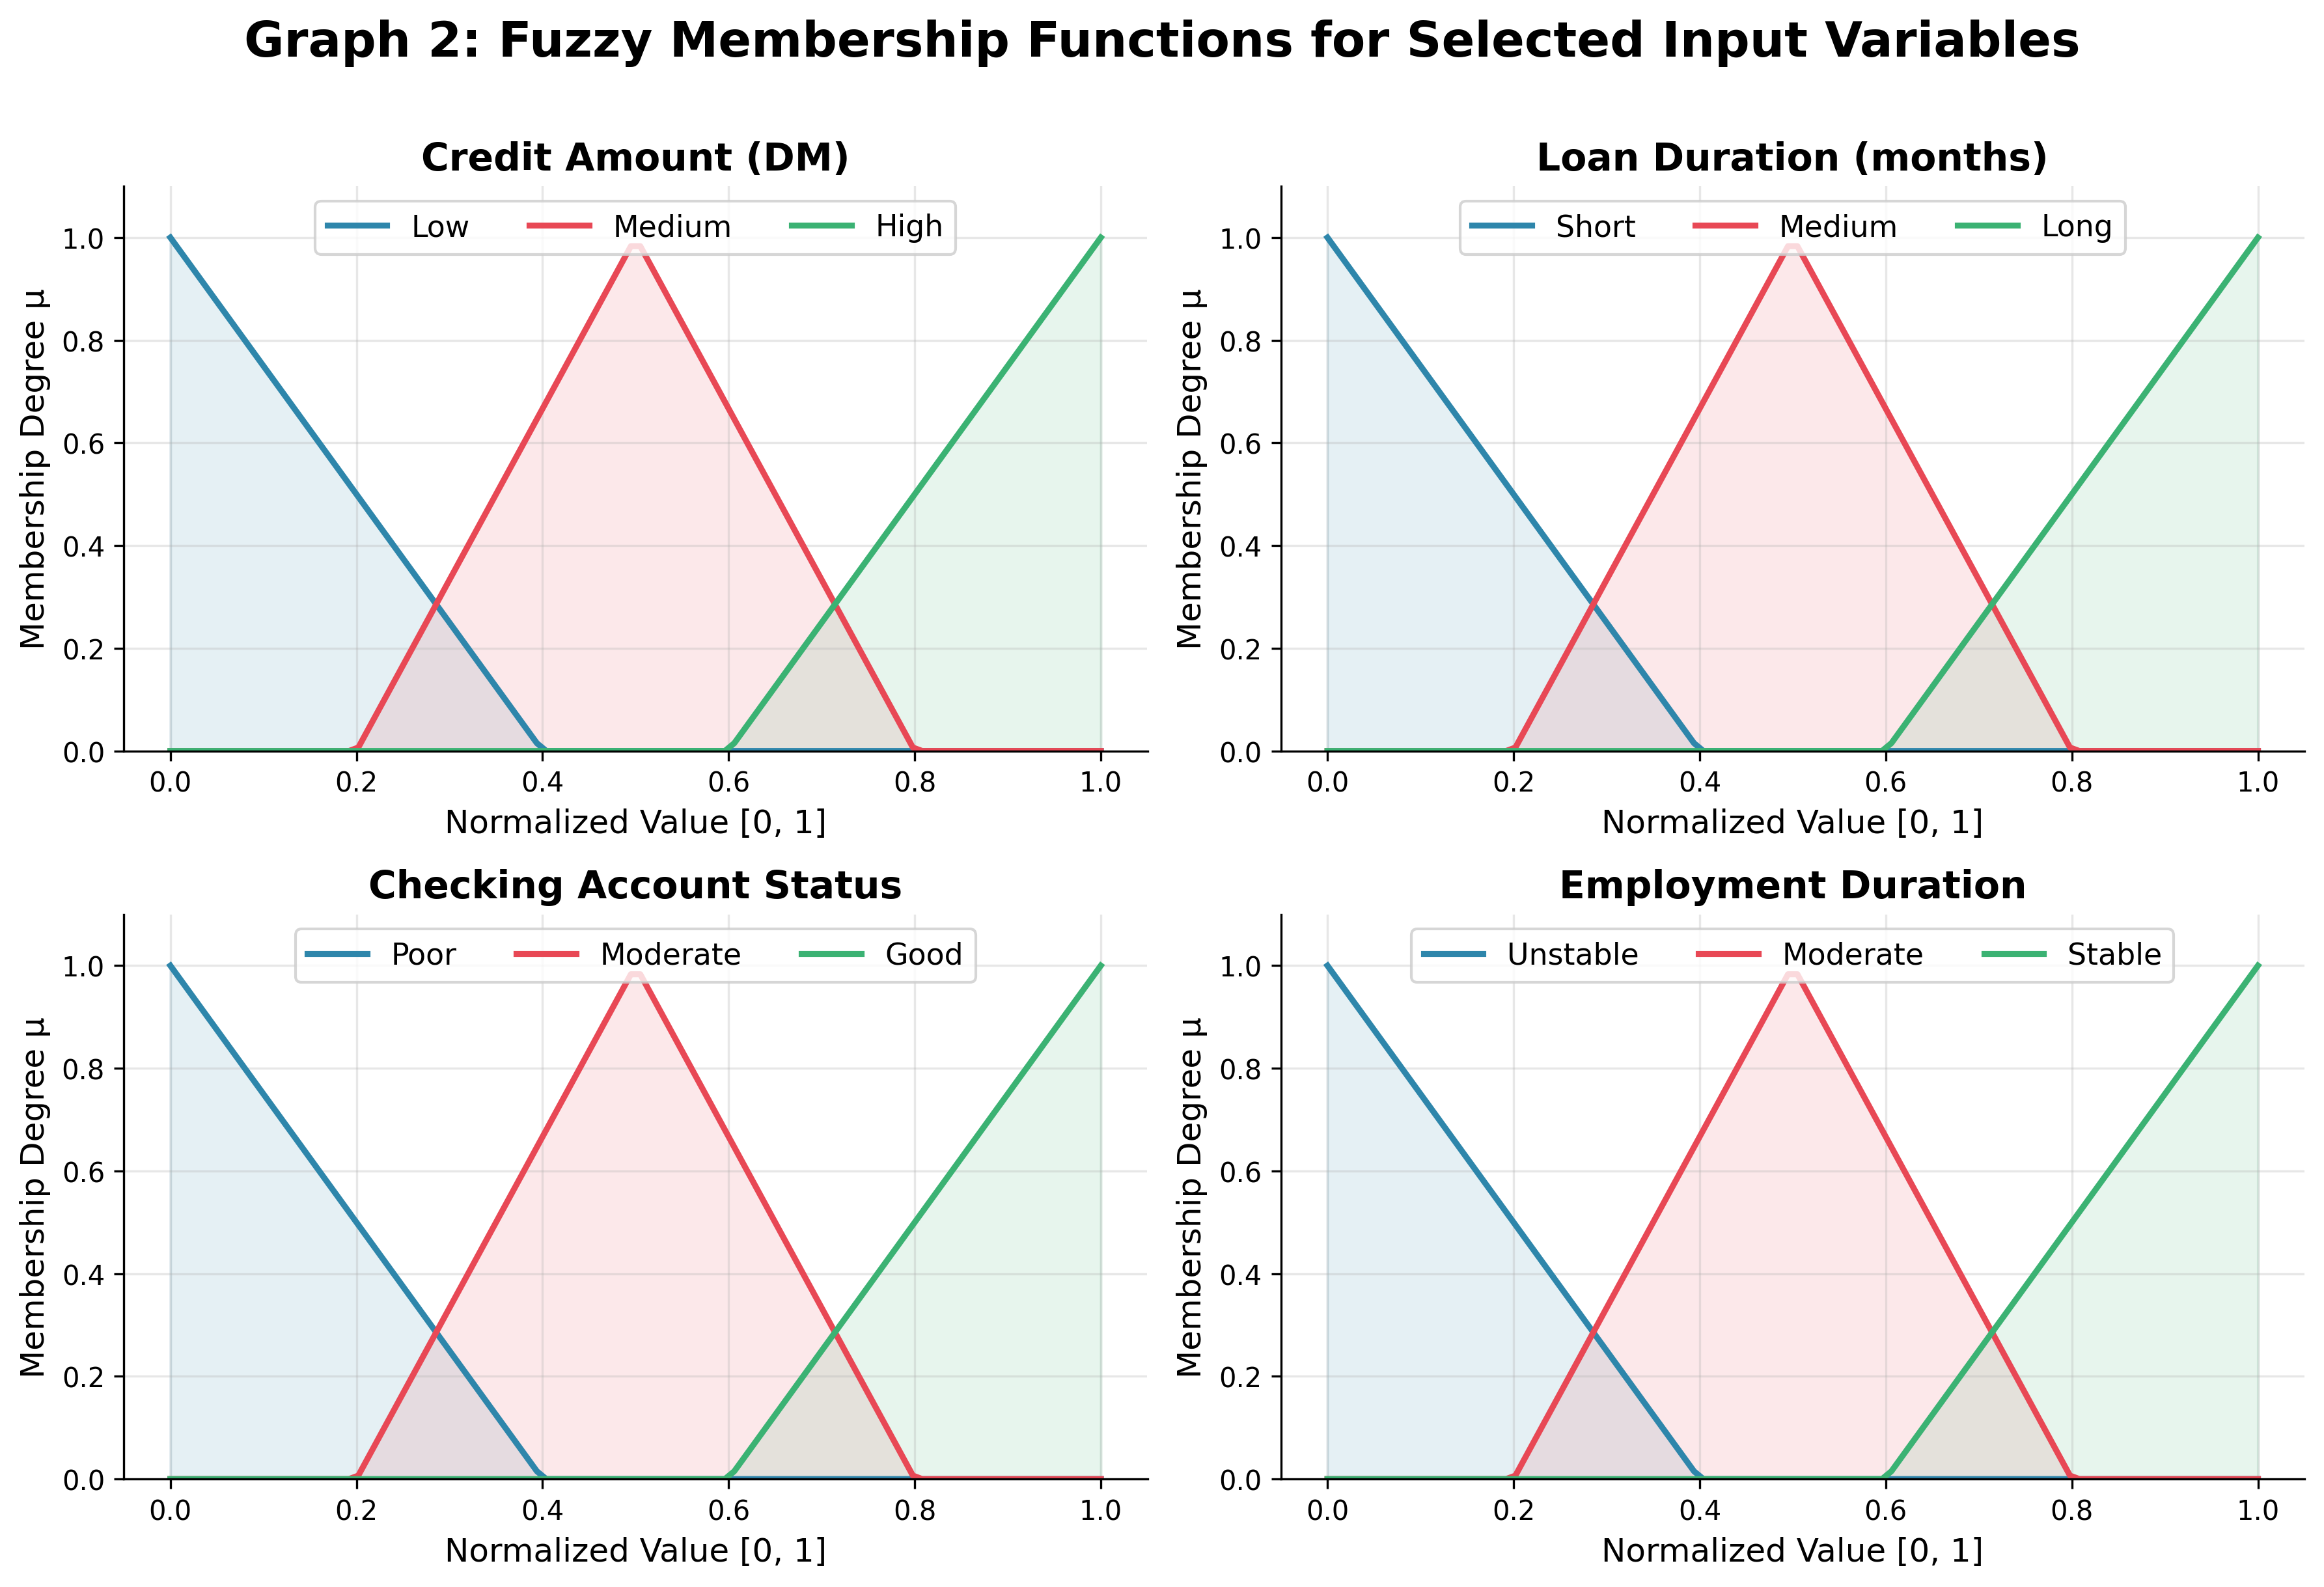

In [10]:
u = np.linspace(0, 1, 100)  # universe of discourse, added for robustness
# ── GRAPH 1: Membership Functions for 4 key variables ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Graph 2: Fuzzy Membership Functions for Selected Input Variables',
             fontsize=18, fontweight='bold', y=1.01) # Increased fontsize

MF_COLORS = ['#2E86AB', '#E84855', '#3BB273']
LABELS_3 = [['Low', 'Medium', 'High'],
            ['Short', 'Medium', 'Long'],
            ['Poor', 'Moderate', 'Good'],
            ['Unstable', 'Moderate', 'Stable']]
TITLES = ['Credit Amount (DM)', 'Loan Duration (months)',
          'Checking Account Status', 'Employment Duration']

for ax, labels, title in zip(axes.flat, LABELS_3, TITLES):
    mf_params = [[0, 0, 0.4], [0.2, 0.5, 0.8], [0.6, 1, 1]]
    for params, label, color in zip(mf_params, labels, MF_COLORS):
        mf = fuzz.trimf(u, params)
        ax.plot(u, mf, color=color, linewidth=2.2, label=label)
        ax.fill_between(u, 0, mf, alpha=0.12, color=color)
    ax.set_title(title, fontsize=14, fontweight='bold') # Increased fontsize
    ax.set_xlabel('Normalized Value [0, 1]', fontsize=12) # Increased fontsize
    ax.set_ylabel('Membership Degree μ', fontsize=12) # Increased fontsize
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=11, loc='upper center', ncol=3) # Increased fontsize
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph1_membership_functions.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 11: GRAPH 2 — ROC Curves Comparison

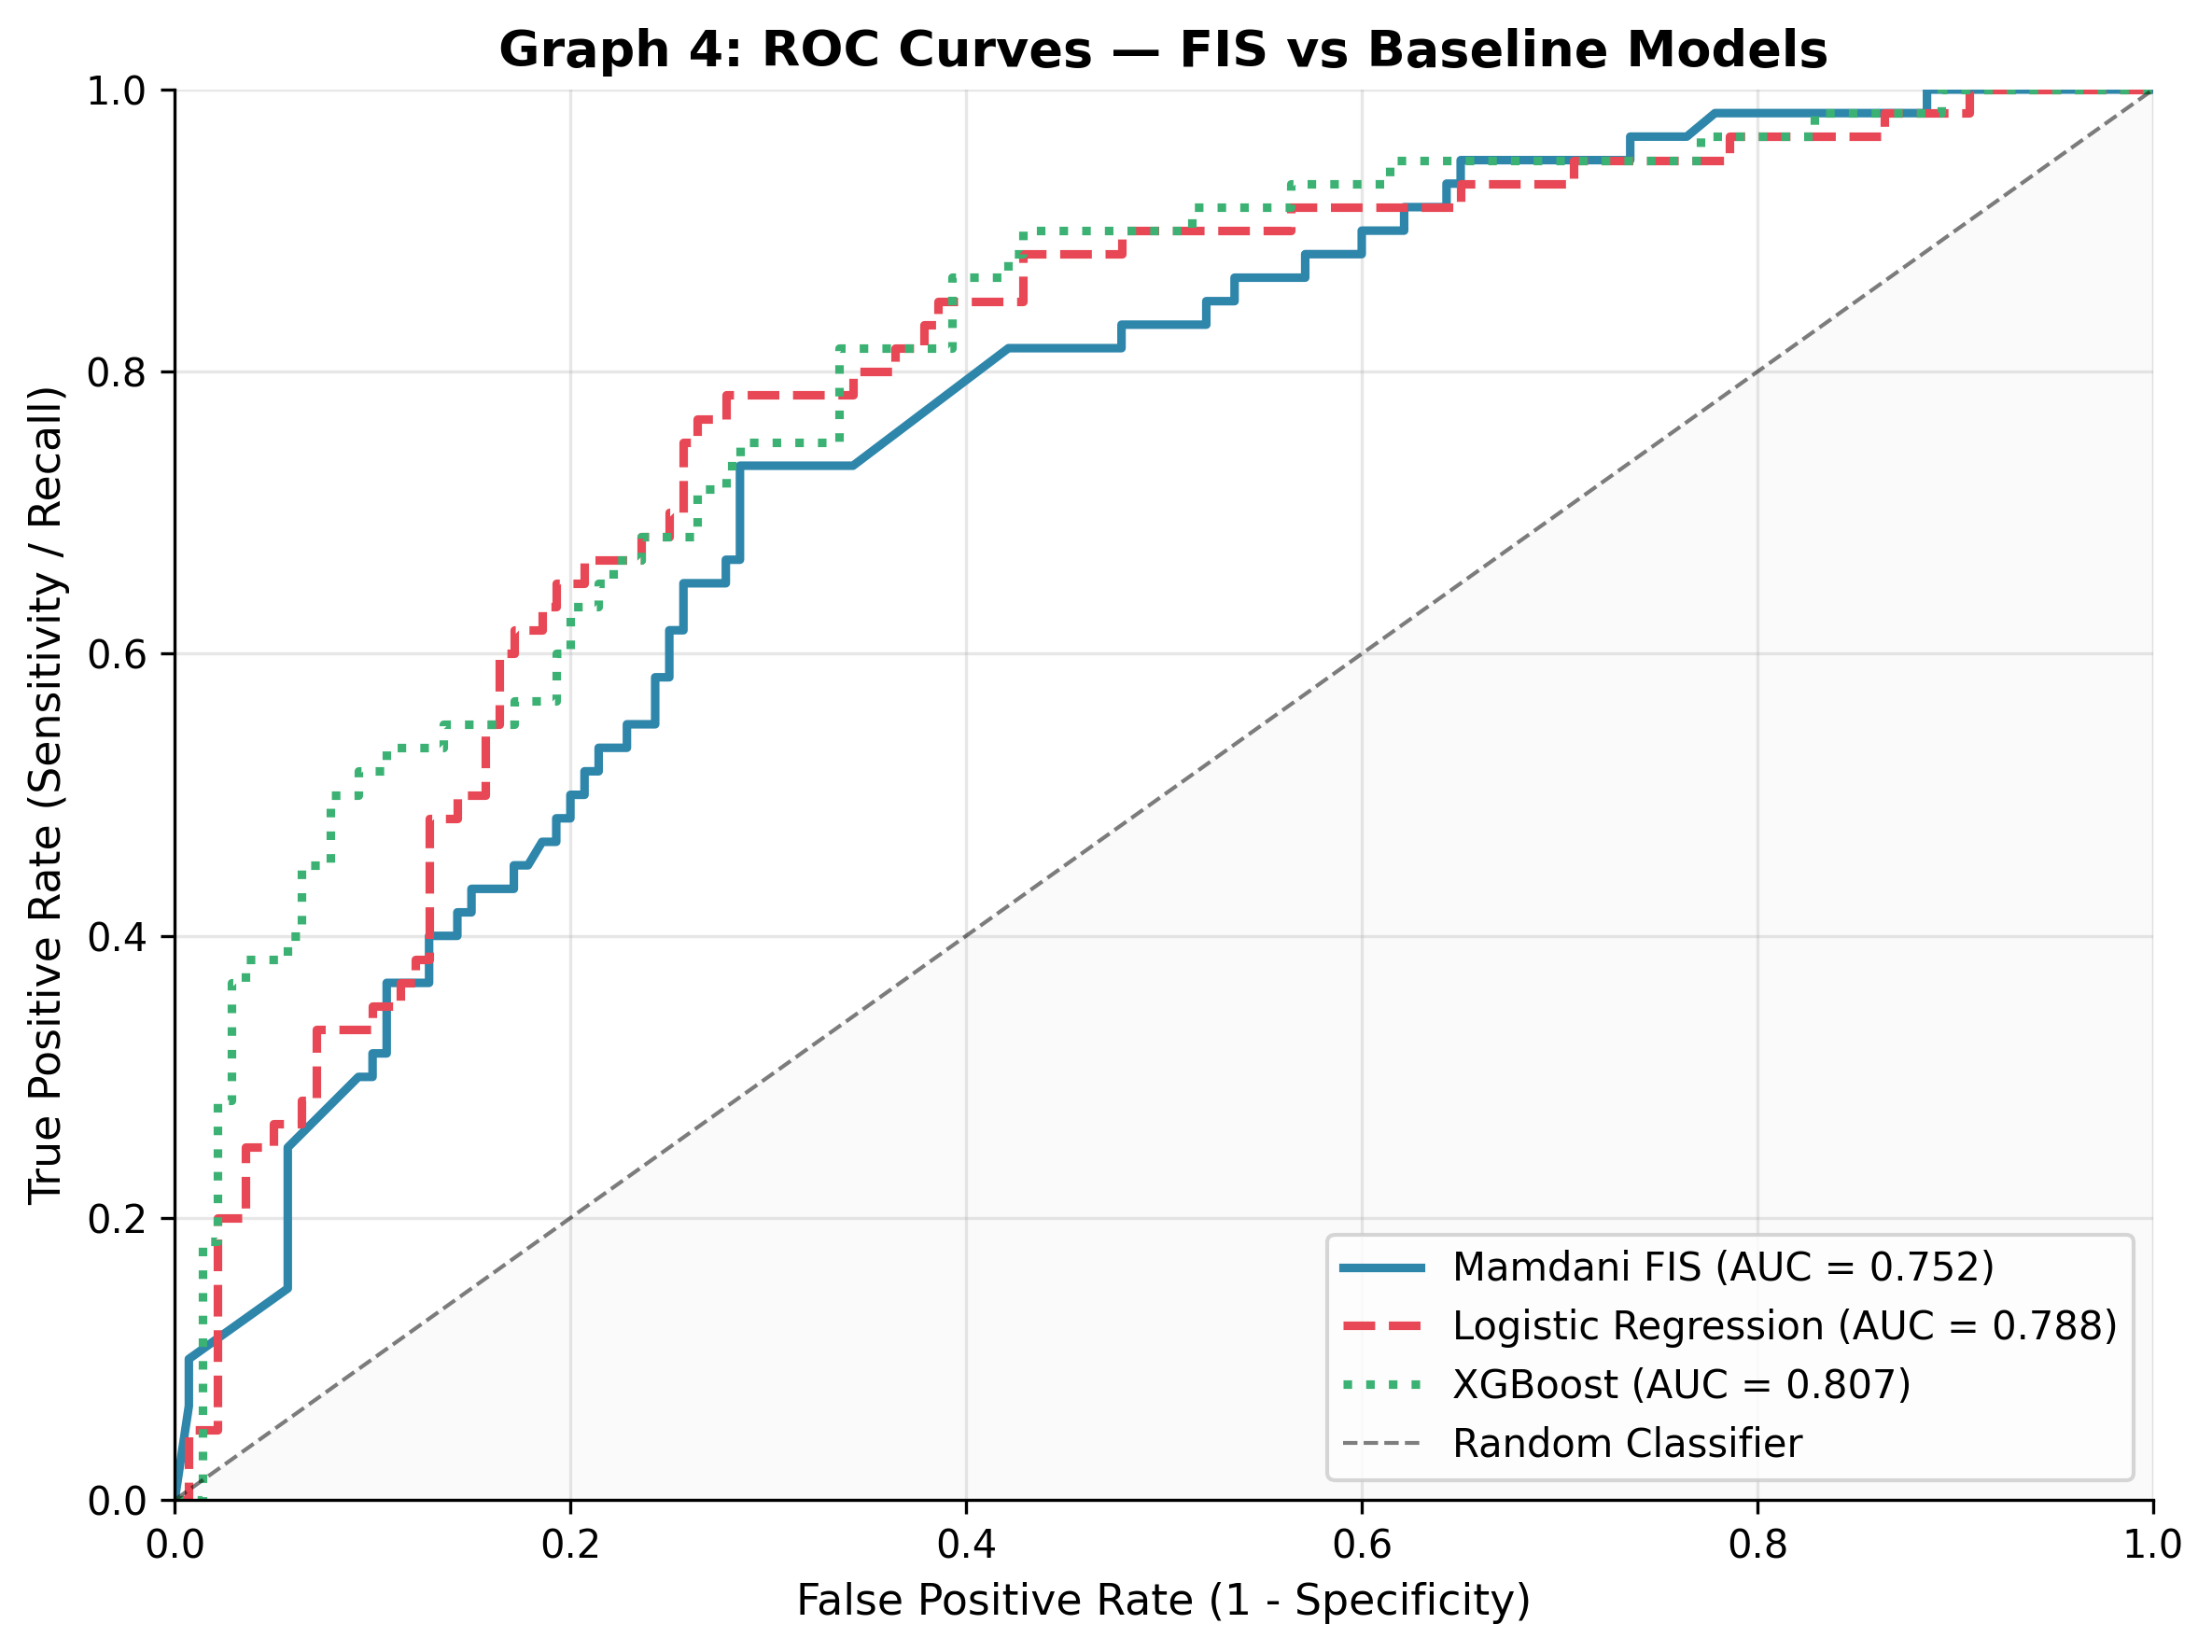

In [11]:
# ── GRAPH 2: ROC Curves ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

models_plot = [
    ('Mamdani FIS',          fis_proba_test, '#2E86AB', '-'),
    ('Logistic Regression',  lr_proba,       '#E84855', '--'),
    ('XGBoost',              xgb_proba,      '#3BB273', ':'),
]

for name, proba, color, ls in models_plot:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.2,
            label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
ax.set_title('Graph 4: ROC Curves — FIS vs Baseline Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.fill_between([0,1],[0,1], alpha=0.04, color='gray')

plt.tight_layout()
plt.savefig('graph2_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 12: GRAPH 3 — Confusion Matrices (All 3 Models)

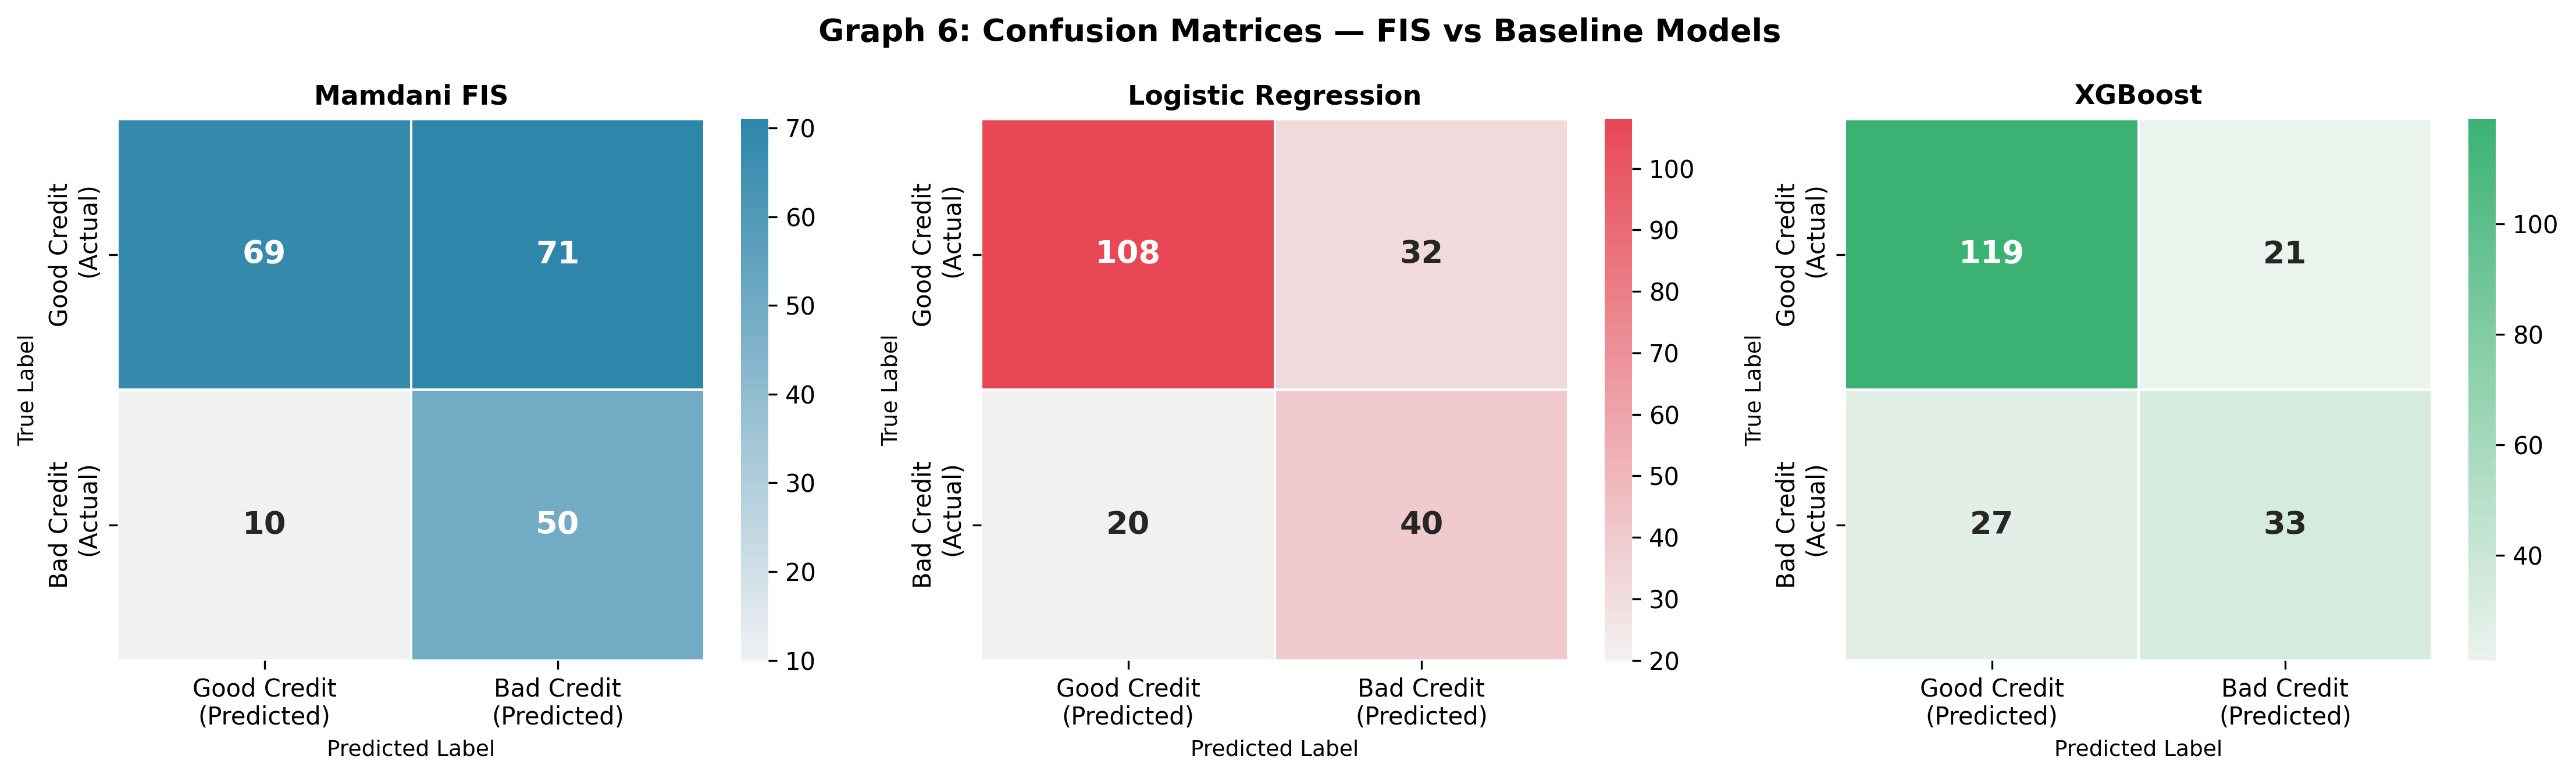

In [12]:
# ── GRAPH 3: Confusion Matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Graph 6: Confusion Matrices — FIS vs Baseline Models',
             fontsize=13, fontweight='bold')

model_preds = [
    ('Mamdani FIS',         fis_pred_test, '#2E86AB'),
    ('Logistic Regression', lr_pred,       '#E84855'),
    ('XGBoost',             xgb_pred,      '#3BB273'),
]

for ax, (name, preds, color) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, preds)
    cmap = sns.light_palette(color, as_cmap=True)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap, ax=ax,
        xticklabels=['Good Credit\n(Predicted)', 'Bad Credit\n(Predicted)'],
        yticklabels=['Good Credit\n(Actual)', 'Bad Credit\n(Actual)'],
        linewidths=0.5, linecolor='white', annot_kws={'size': 13, 'weight': 'bold'}
    )
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

plt.tight_layout()
plt.savefig('graph3_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 13: GRAPH 4 — Metric Comparison Bar Chart

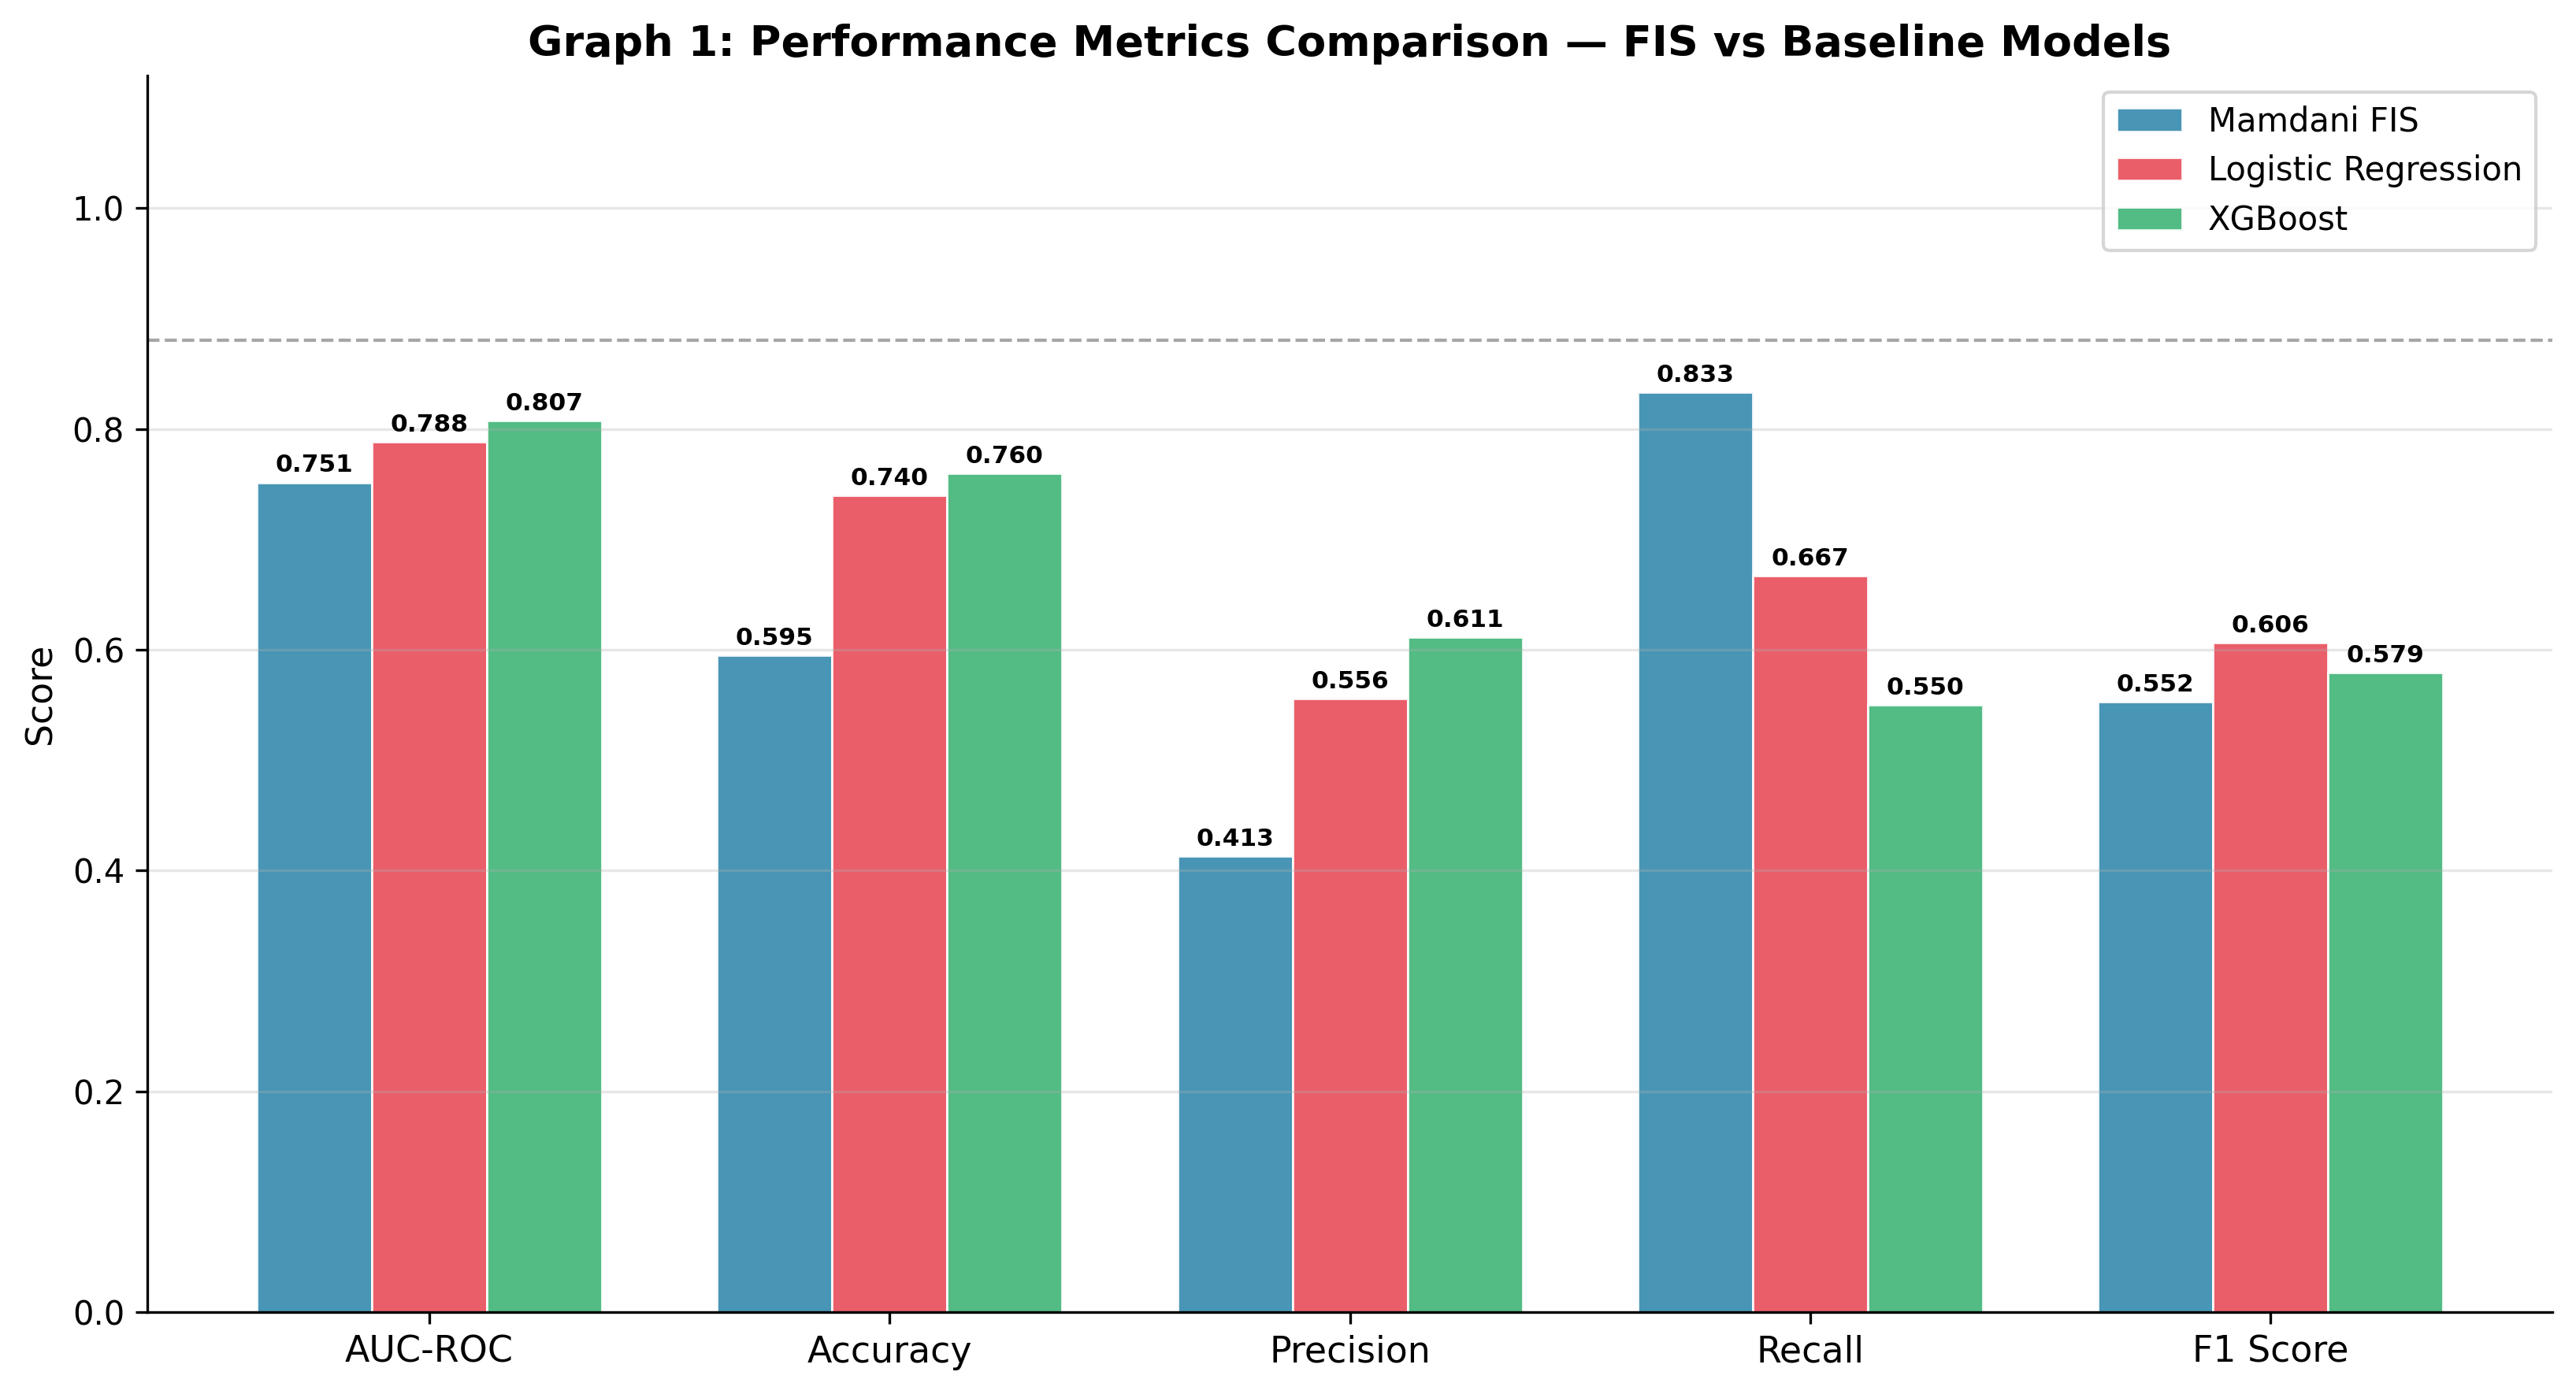

In [13]:
# ── GRAPH 4: Performance Metrics Comparison ───────────────────────────────────
metrics_to_plot = ['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

colors_bar = ['#2E86AB', '#E84855', '#3BB273']
for i, (row, color) in enumerate(zip([metrics_fis, metrics_lr, metrics_xgb], colors_bar)):
    vals = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + i*width - width, vals, width, label=row['Model'],
                  color=color, alpha=0.88, edgecolor='white', linewidth=0.7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Graph 1: Performance Metrics Comparison — FIS vs Baseline Models',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.88, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Target AUC')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graph4_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 14: GRAPH 5 — Precision-Recall Curves

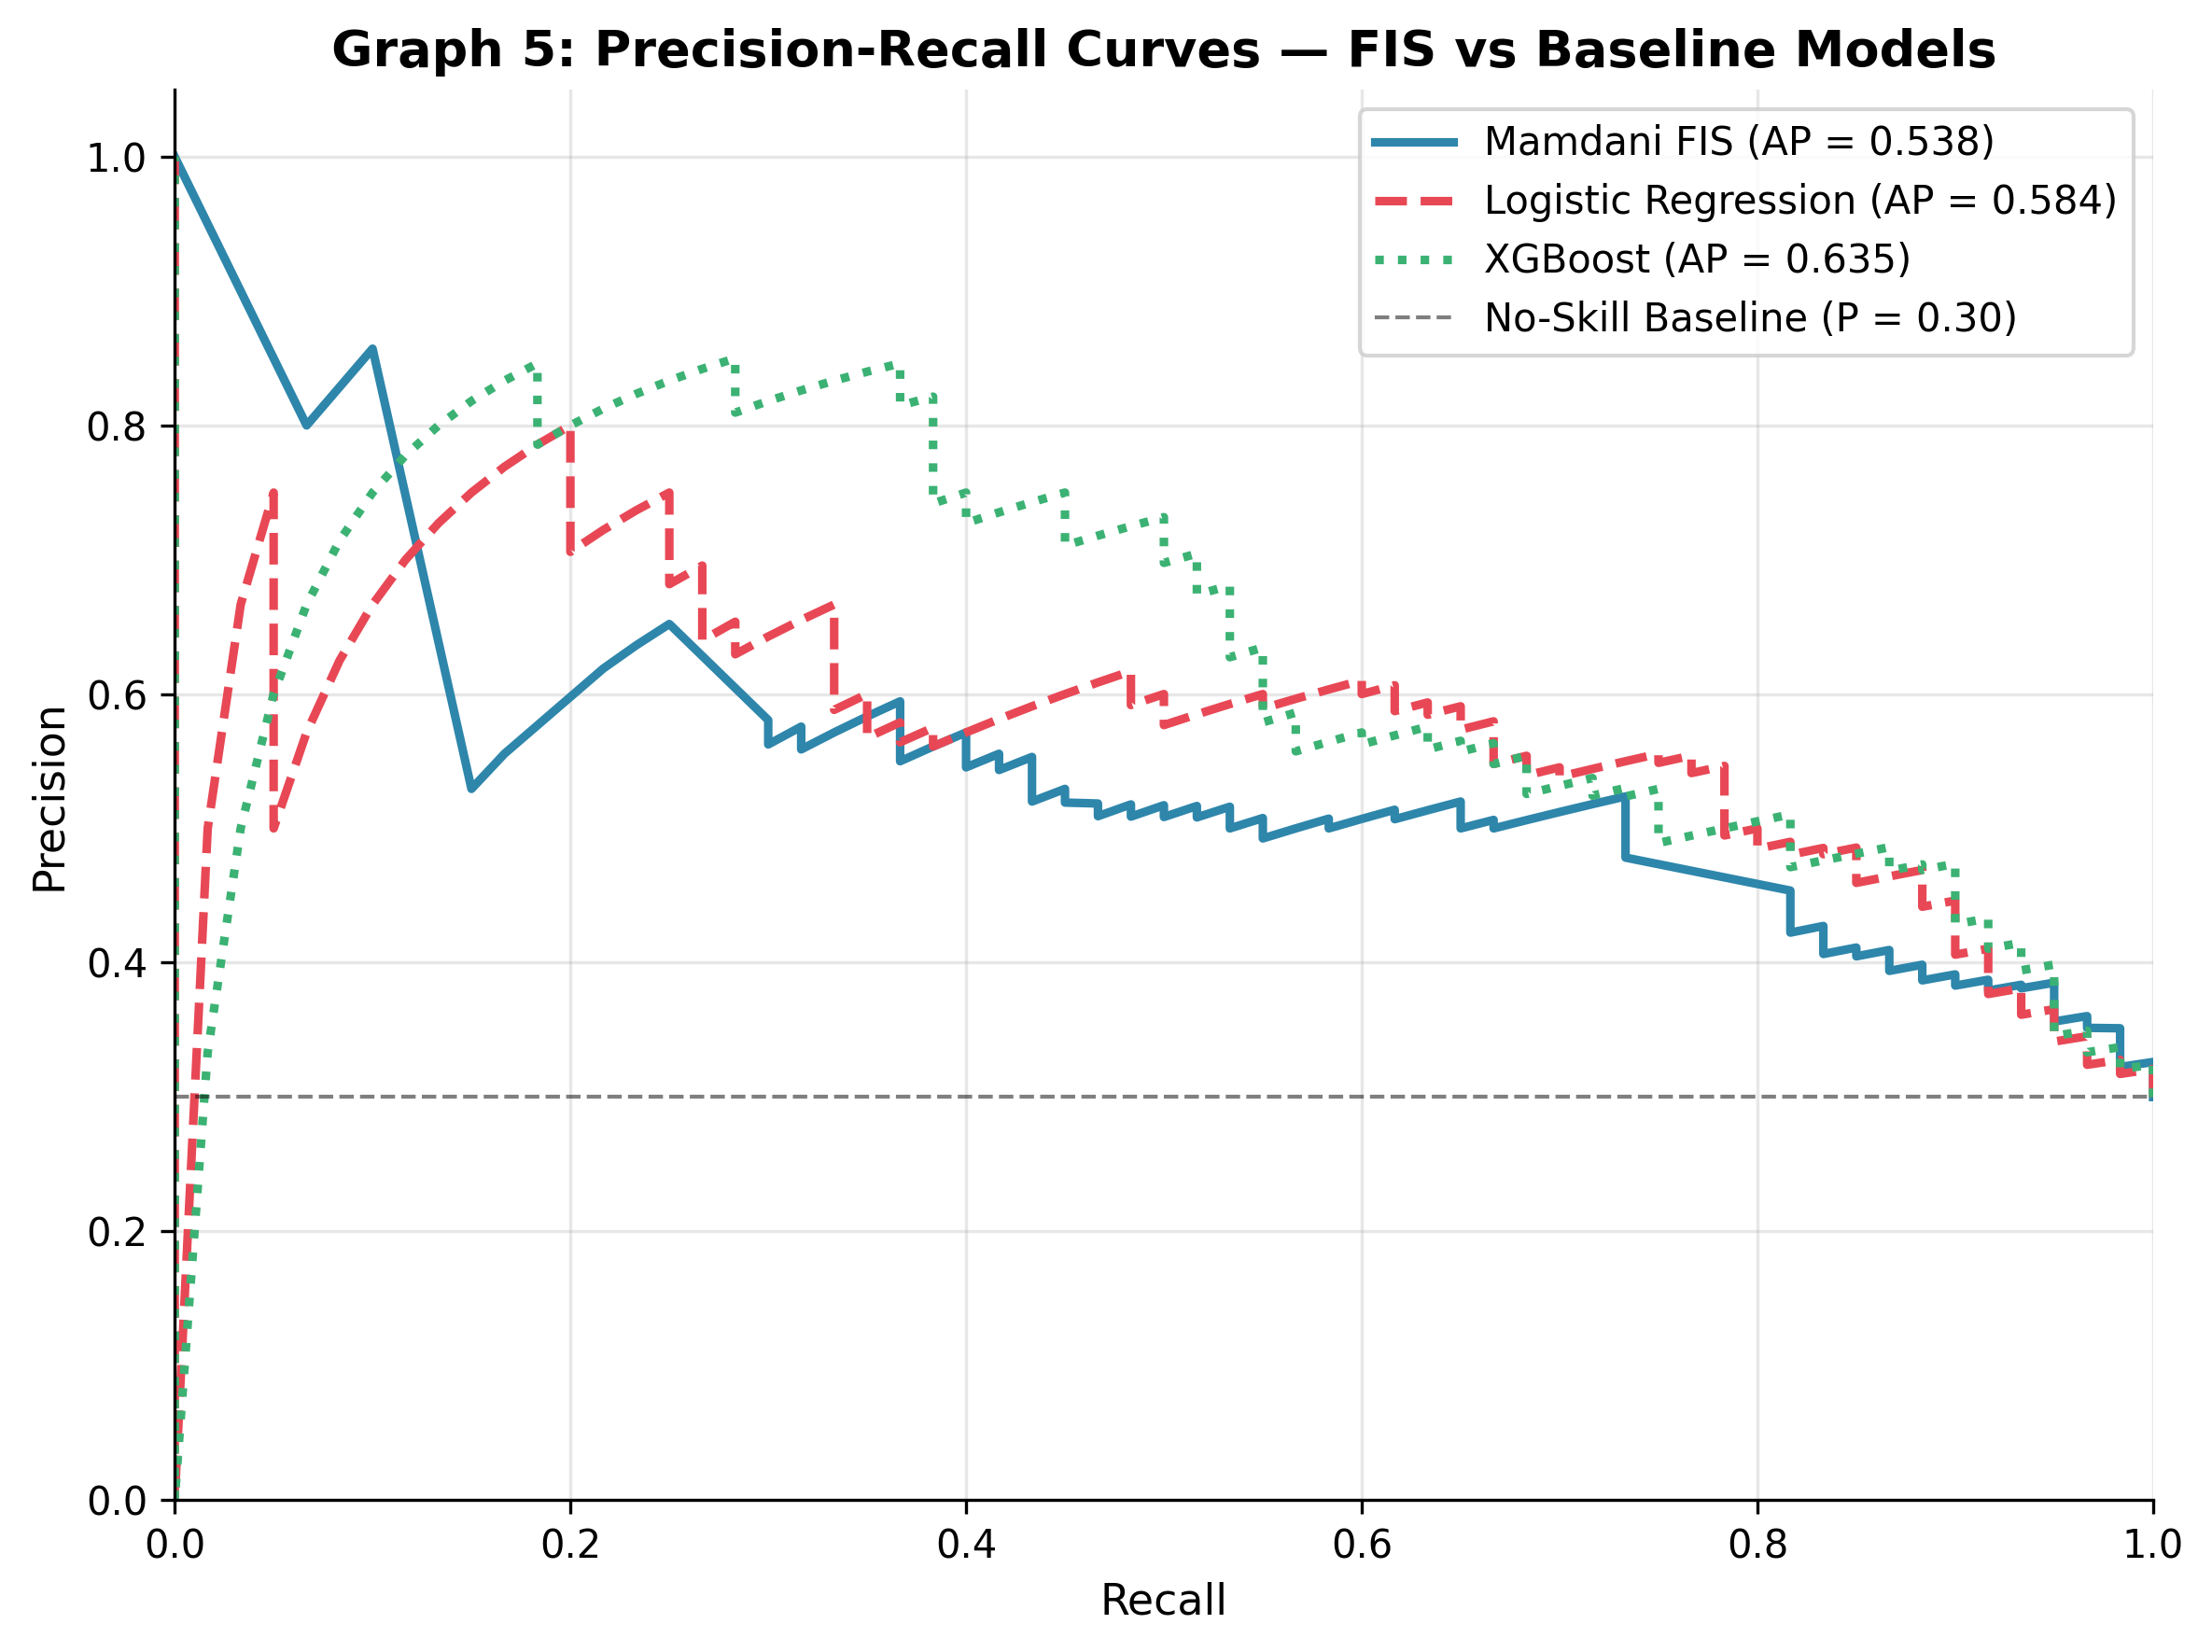

In [14]:
# ── GRAPH 5: Precision-Recall Curves ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color, ls in models_plot:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=color, linestyle=ls, linewidth=2.2,
            label=f'{name} (AP = {ap:.3f})')

baseline_pr = y_test.mean()
ax.axhline(baseline_pr, color='k', linestyle='--', linewidth=1, alpha=0.5,
           label=f'No-Skill Baseline (P = {baseline_pr:.2f})')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Graph 5: Precision-Recall Curves — FIS vs Baseline Models',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph5_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 15: GRAPH 6 — PD Score Distribution

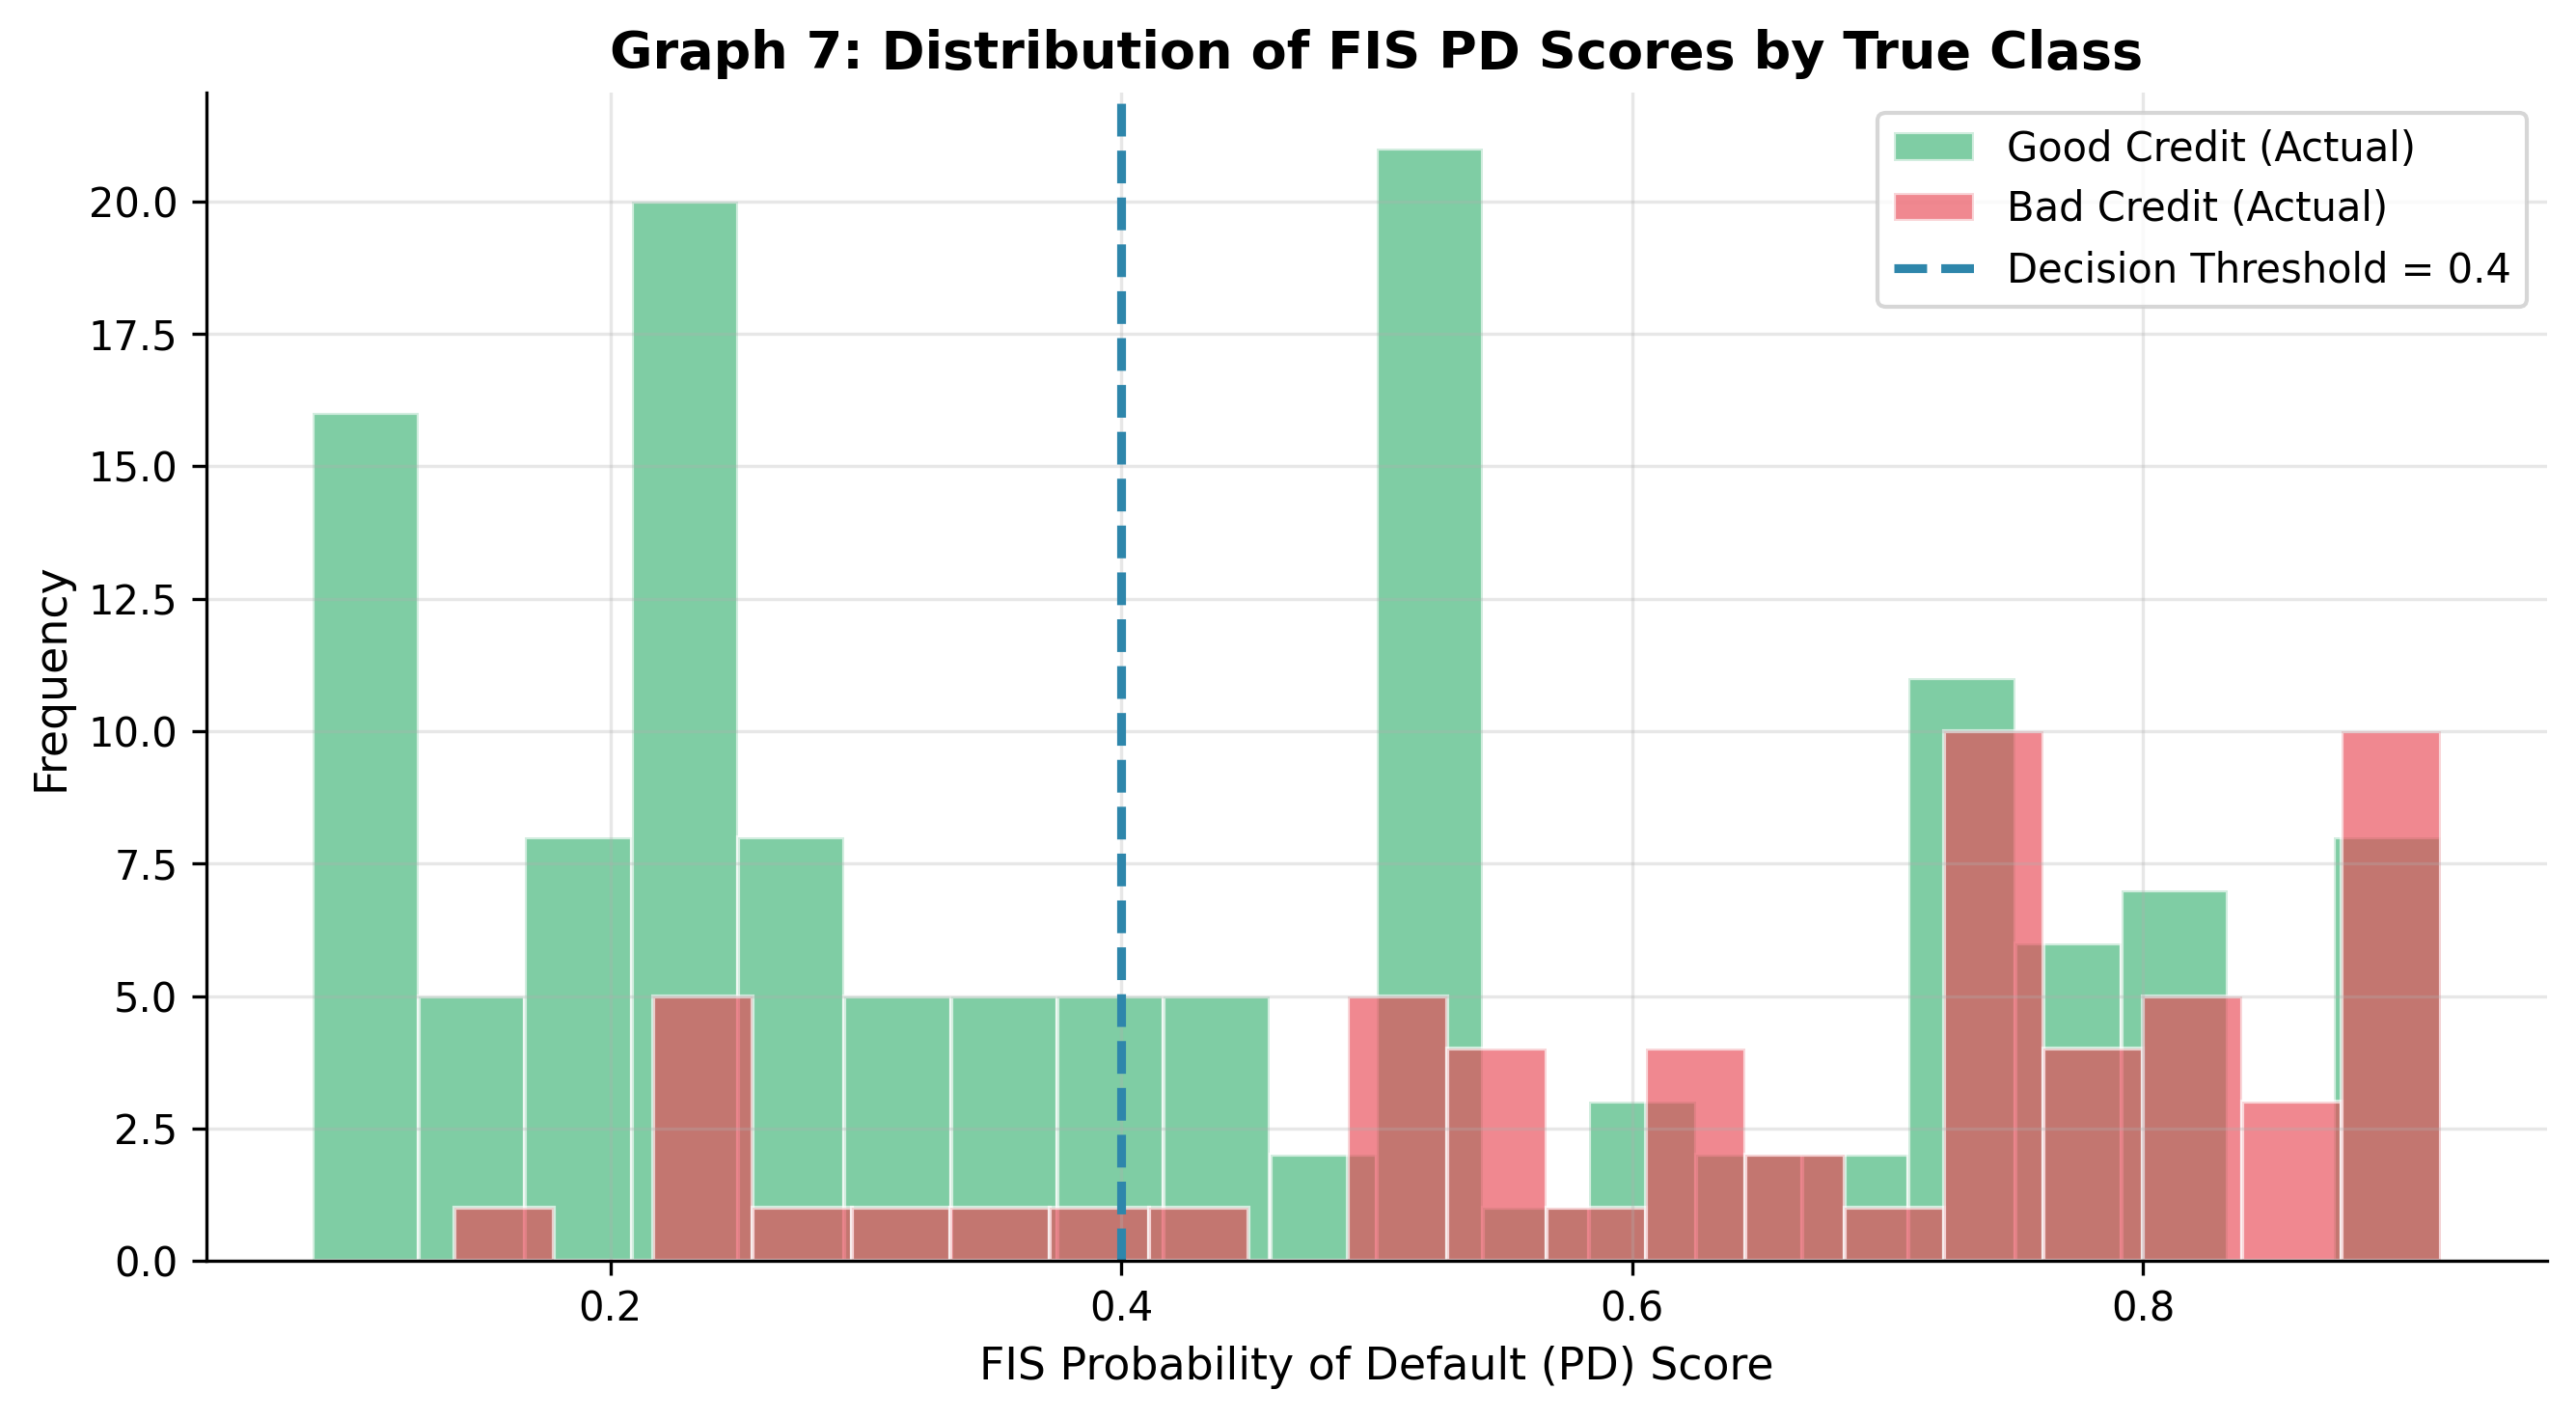

In [15]:
# ── GRAPH 6: FIS PD Score Distribution by True Class ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

good_scores = fis_proba_test[y_test == 0]
bad_scores  = fis_proba_test[y_test == 1]

ax.hist(good_scores, bins=20, alpha=0.65, color='#3BB273', label='Good Credit (Actual)', edgecolor='white')
ax.hist(bad_scores,  bins=20, alpha=0.65, color='#E84855', label='Bad Credit (Actual)',  edgecolor='white')
ax.axvline(THRESHOLD, color='#2E86AB', linewidth=2.2, linestyle='--',
           label=f'Decision Threshold = {THRESHOLD}')

ax.set_xlabel('FIS Probability of Default (PD) Score', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Graph 7: Distribution of FIS PD Scores by True Class',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph6_pd_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 16: GRAPH 7 — Thin-File Subset Analysis (Financial Inclusion)

Thin-file test records: 151 out of 200


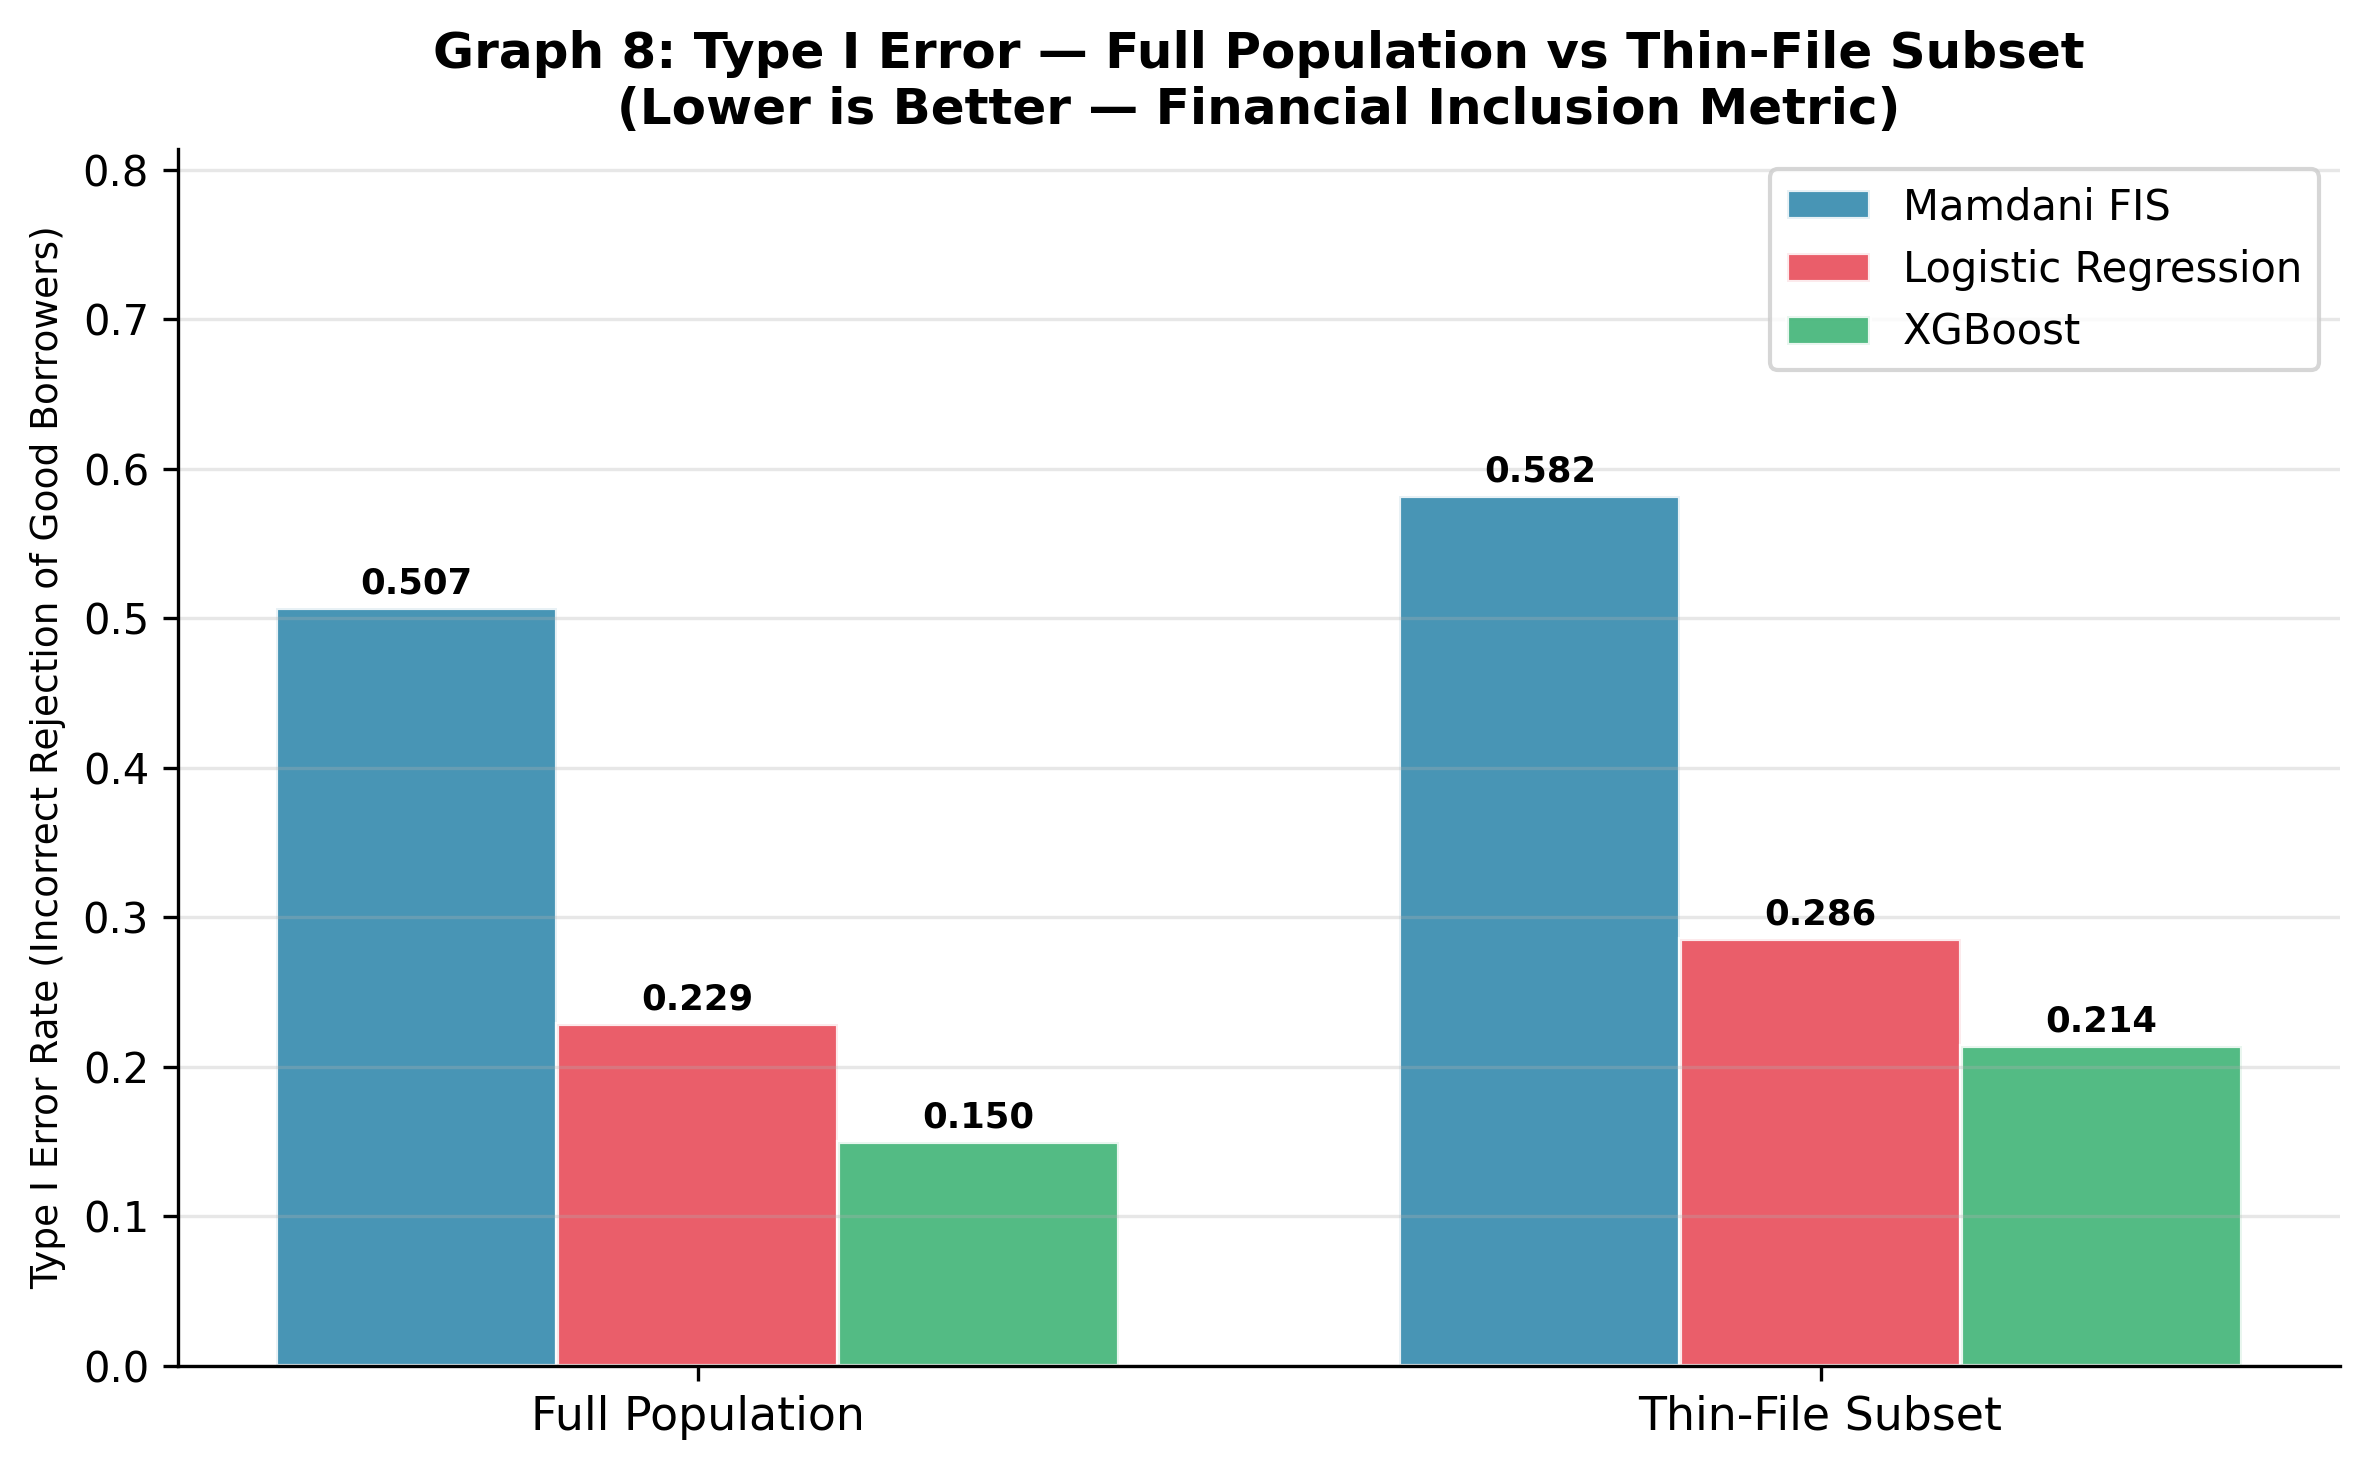

In [16]:
# ── GRAPH 7: Thin-File Borrower Type I Error Comparison ──────────────────────
# Define thin-file: checking_status == 'Poor' (encoded as 0) OR no savings (low savings)
# We identify thin-file records in the test set

# Get original test indices in X_test_sc
checking_idx = feature_names.index('checking_status') if 'checking_status' in feature_names else 0
savings_idx  = feature_names.index('savings_account')  if 'savings_account'  in feature_names else 1

# Thin-file: checking_status in lowest tercile AND savings in lowest tercile
thin_mask = (X_test_sc[:, checking_idx] < 0.33) | (X_test_sc[:, savings_idx] < 0.33)
print(f'Thin-file test records: {thin_mask.sum()} out of {len(thin_mask)}')

def type1_rate(y_true, y_pred, mask):
    """Type I Error rate (FPR) on a subset."""
    yt = y_true[mask]; yp = y_pred[mask]
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0

# Full population
t1_full_fis = metrics_fis['Type I Error']
t1_full_lr  = metrics_lr['Type I Error']
t1_full_xgb = metrics_xgb['Type I Error']

# Thin-file subset
t1_thin_fis = type1_rate(y_test, fis_pred_test, thin_mask)
t1_thin_lr  = type1_rate(y_test, lr_pred,        thin_mask)
t1_thin_xgb = type1_rate(y_test, xgb_pred,       thin_mask)

categories = ['Full Population', 'Thin-File Subset']
fis_vals = [t1_full_fis, t1_thin_fis]
lr_vals  = [t1_full_lr,  t1_thin_lr]
xgb_vals = [t1_full_xgb, t1_thin_xgb]

x_g7 = np.arange(len(categories))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x_g7 - w, fis_vals, w, label='Mamdani FIS',         color='#2E86AB', alpha=0.88, edgecolor='white')
ax.bar(x_g7,     lr_vals,  w, label='Logistic Regression', color='#E84855', alpha=0.88, edgecolor='white')
ax.bar(x_g7 + w, xgb_vals, w, label='XGBoost',             color='#3BB273', alpha=0.88, edgecolor='white')

for vals, offset in zip([fis_vals, lr_vals, xgb_vals], [-w, 0, w]):
    for xi, v in zip(x_g7, vals):
        ax.text(xi + offset, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x_g7)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Type I Error Rate (Incorrect Rejection of Good Borrowers)', fontsize=9)
ax.set_title('Graph 8: Type I Error — Full Population vs Thin-File Subset\n(Lower is Better — Financial Inclusion Metric)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(fis_vals+lr_vals+xgb_vals)*1.4, 0.3))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graph7_financial_inclusion.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 17: GRAPH 8 — Feature Importance (Fisher Scores)

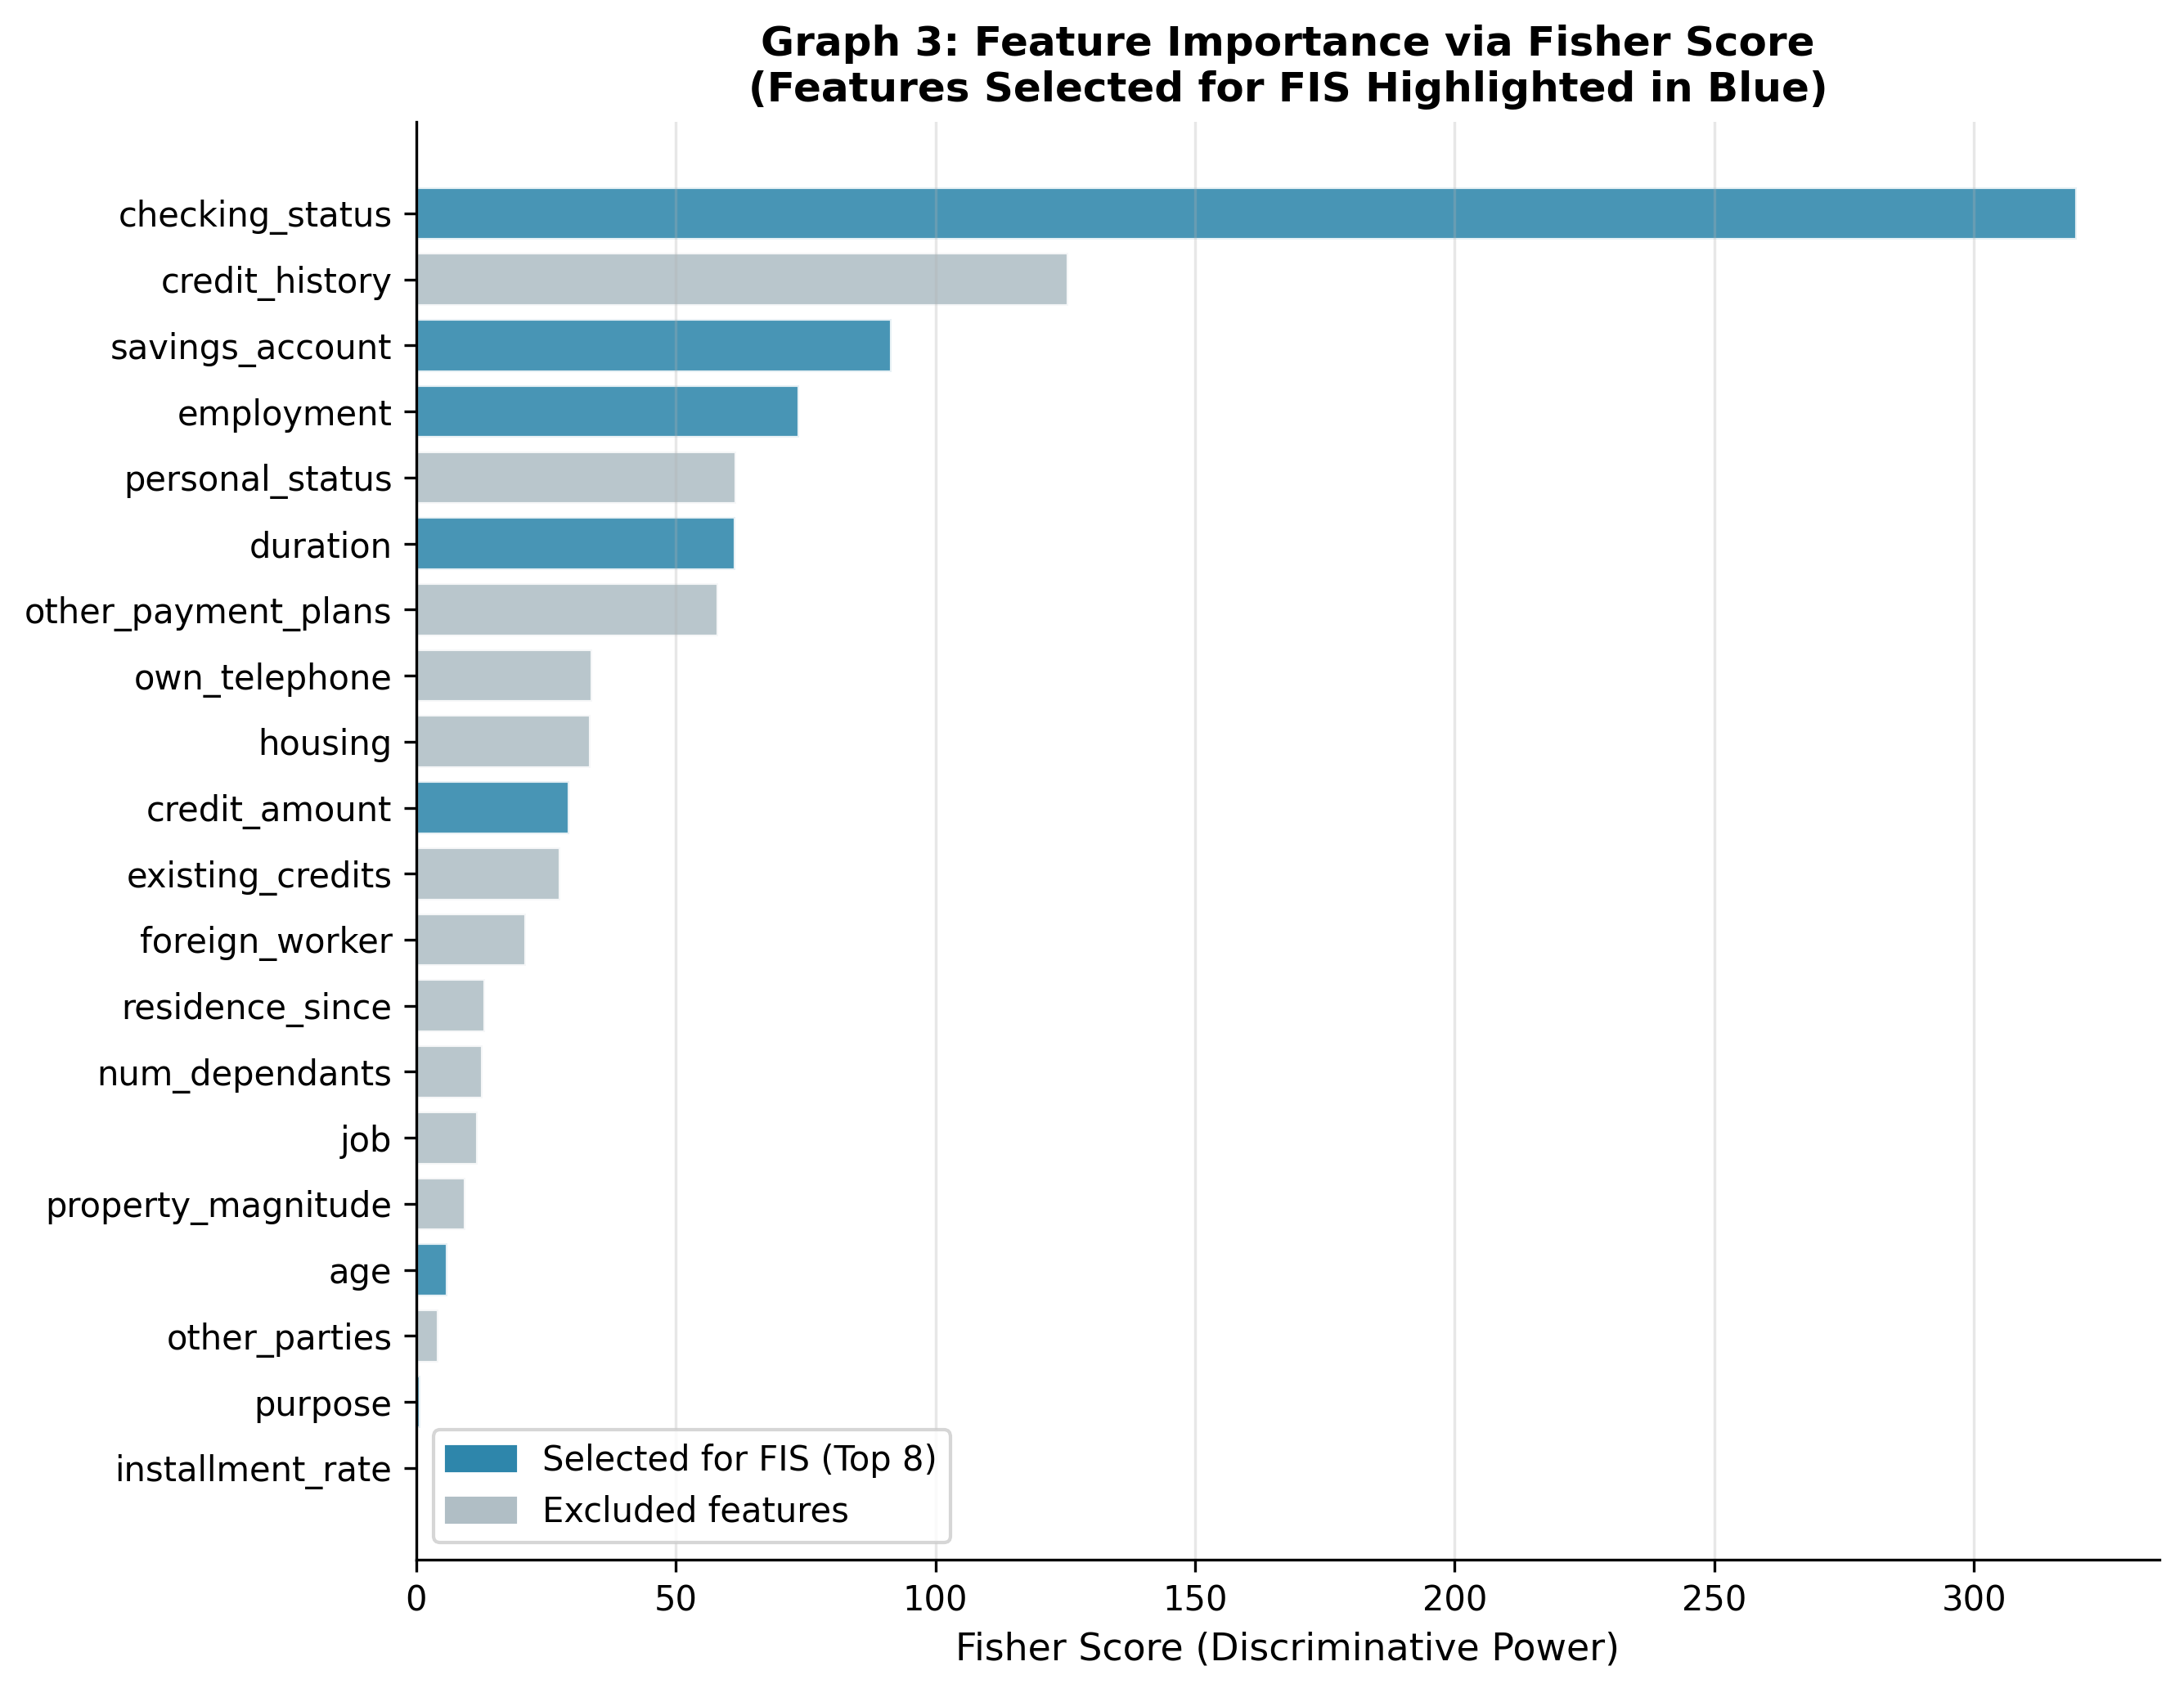

In [17]:
# ── GRAPH 8: Feature Importance from Fisher Score ─────────────────────────────
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Fisher Score': fisher_scores
}).sort_values('Fisher Score', ascending=True)

# Highlight FIS-selected features
fis_features_set = set(TARGET_COLS)
bar_colors = ['#2E86AB' if f in fis_features_set else '#B0BEC5' for f in importance_df['Feature']]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(importance_df['Feature'], importance_df['Fisher Score'],
               color=bar_colors, edgecolor='white', alpha=0.88)

patch_sel = mpatches.Patch(color='#2E86AB', label='Selected for FIS (Top 8)')
patch_oth = mpatches.Patch(color='#B0BEC5', label='Excluded features')
ax.legend(handles=[patch_sel, patch_oth], fontsize=10)

ax.set_xlabel('Fisher Score (Discriminative Power)', fontsize=11)
ax.set_title('Graph 3: Feature Importance via Fisher Score\n(Features Selected for FIS Highlighted in Blue)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('graph8_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Cell 18: Summary Performance Table (Print & Export)

In [18]:
# ── Full Performance Table ────────────────────────────────────────────────────
print('='*85)
print('TABLE: Model Performance Comparison on German Credit Dataset (Test Set, n=200)')
print('='*85)
print(results_df[['Model','AUC-ROC','Accuracy','Precision','Recall',
                   'F1 Score','Type I Error','Type II Error']].to_string(index=False))
print('='*85)
print('\nType I Error  = False Positive Rate (good borrowers incorrectly rejected)')
print('Type II Error = False Negative Rate (defaulters incorrectly approved)')

# Thin-file results
thin_results = {
    'Model': ['Mamdani FIS', 'Logistic Regression', 'XGBoost'],
    'Type I Error (Full)':  [t1_full_fis, t1_full_lr, t1_full_xgb],
    'Type I Error (Thin-File)': [t1_thin_fis, t1_thin_lr, t1_thin_xgb],
}
thin_df = pd.DataFrame(thin_results)
print('\nTABLE: Type I Error — Financial Inclusion Analysis')
print(thin_df.round(4).to_string(index=False))

# Export to CSV for LaTeX table use
results_df.to_csv('performance_table.csv', index=False)
thin_df.to_csv('thin_file_table.csv', index=False)
print('\nTables exported to CSV.')

TABLE: Model Performance Comparison on German Credit Dataset (Test Set, n=200)
              Model  AUC-ROC  Accuracy  Precision  Recall  F1 Score  Type I Error  Type II Error
        Mamdani FIS   0.7515     0.595     0.4132  0.8333    0.5525        0.5071         0.1667
Logistic Regression   0.7882     0.740     0.5556  0.6667    0.6061        0.2286         0.3333
            XGBoost   0.8073     0.760     0.6111  0.5500    0.5789        0.1500         0.4500

Type I Error  = False Positive Rate (good borrowers incorrectly rejected)
Type II Error = False Negative Rate (defaulters incorrectly approved)

TABLE: Type I Error — Financial Inclusion Analysis
              Model  Type I Error (Full)  Type I Error (Thin-File)
        Mamdani FIS               0.5071                    0.5816
Logistic Regression               0.2286                    0.2857
            XGBoost               0.1500                    0.2143

Tables exported to CSV.


## Cell 19: Save All Graphs Summary

In [19]:
import os
graphs = [
    'graph1_membership_functions.png',
    'graph2_roc_curves.png',
    'graph3_confusion_matrices.png',
    'graph4_metrics_comparison.png',
    'graph5_precision_recall.png',
    'graph6_pd_distribution.png',
    'graph7_financial_inclusion.png',
    'graph8_feature_importance.png',
]
print('Generated graph files:')
for g in graphs:
    exists = os.path.isfile(g)
    size = f'{os.path.getsize(g)/1024:.1f} KB' if exists else 'MISSING'
    print(f'  {"✅" if exists else "❌"} {g}  ({size})')
print('\nAll done! Download these files and include them in your LaTeX document.')

Generated graph files:
  ✅ graph1_membership_functions.png  (514.8 KB)
  ✅ graph2_roc_curves.png  (229.5 KB)
  ✅ graph3_confusion_matrices.png  (203.0 KB)
  ✅ graph4_metrics_comparison.png  (154.2 KB)
  ✅ graph5_precision_recall.png  (245.4 KB)
  ✅ graph6_pd_distribution.png  (129.4 KB)
  ✅ graph7_financial_inclusion.png  (151.4 KB)
  ✅ graph8_feature_importance.png  (231.8 KB)

All done! Download these files and include them in your LaTeX document.
